## Papers Relevant to This Topic

- **Kapsch et al. (2016)**  
  *The Effect of Downwelling Longwave and Shortwave Radiation on Arctic Summer Sea Ice*  
  https://doi.org/10.1175/JCLI-D-15-0238.1  

- **Sicard et al. (2023)**  
  *Similarities and Differences in Arctic Sea-Ice Loss During the Solar-Forced Last Interglacial Warming (127 Kyr BP) and CO₂-Forced Future Warming*  
  https://doi.org/10.1029/2023GL104782  

- **Sicard et al. (2025)**  
  *Variations in Arctic Ocean Dynamics and Hydrography Under 127 ka Last Interglacial Conditions and Future Warming*  
  https://doi.org/10.1029/2025PA005247  

- **Drobot et al. (2006)**  
  *A Long-Range Forecast of Arctic Summer Sea-Ice Minimum Extent*  
  https://doi.org/10.1029/2006GL026216  

- **Murto et al. (2026)**  
  *Characteristics of Springtime Surface Energy Budget Anomalies and Their Relation to Arctic Melt Onset Dates*  
  https://doi.org/10.1175/JCLI-D-25-0382.1  

  Highlights that melt onset (and thus Sep SIA) are governed by anomalies in the surface energy balance. 

- **Murto et al. (2023)**  
  *Extreme Surface Energy Budget Anomalies in the High Arctic in Winter*  
  https://doi.org/10.1175/JCLI-D-22-0209.1  

- **Kim et al. (2021)**  
  *A Regional Seasonal Forecast Model of Arctic Minimum Sea Ice Extent: Reflected Solar Radiation versus Late Winter Coastal Divergence*  
  https://doi.org/10.1175/JCLI-D-20-0846.1  

- **Huang et al. (2019)**  
  *Radiative Control of the Interannual Variability of Arctic Sea Ice*  
  https://doi.org/10.1029/2019GL084204  

- **Kapsch et al. (2014)**  
  *The Importance of Spring Atmospheric Conditions for Predictions of the Arctic Summer Sea Ice Extent*  
  https://doi.org/10.1002/2014GL060826  
  
  Shows that predictions of September sea ice can be based on only two atmospheric variables (ignoring ocean etc).
  Achieves ok prediction from several months out, but highlights the difficulty of going longer.
  This reinforces the result we get here, since the peak of importance is June / July. 

  Also goes in to detail about the (negative) correlation between LW and SW radiation.
  This is good as it reinforces the benefit of using a paleo experiment where SW is orbitally forced. 

- **Kapsch et al. (2013)**  
  *Springtime Atmospheric Energy Transport and the Control of Arctic Summer Sea-Ice Extent*  
  https://doi.org/10.1038/nclimate1884  

  **Park et al. (2026)**
  *Weakening Atmospheric Control of Arctic Sea Ice Radiative Forcing Following the Mid-2000s Regime Shift*
  [https://iopscience.iop.org/article/10.1088/2515-7620/ae6f8e/pdf](https://iopscience.iop.org/article/10.1088/2515-7620/ae6f8e/pdf)

In [1]:
# Import various python packages

import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_categorisation as icc
from iris.time import PartialDateTime
import iris.analysis

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd

import os
import warnings 
import io

import cartopy.io.shapereader as shpreader


from matplotlib.path import Path
import matplotlib.patches as mpatches
import calendar
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import get_cmap

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from scipy.optimize import minimize
from scipy.stats import norm

from scipy.interpolate import PchipInterpolator
from scipy.optimize import differential_evolution

import operator

import pickle
from copy import deepcopy
from pathlib import Path

warnings.filterwarnings('ignore') 

In [2]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


In [3]:
VAR_META = {
    "siconc": {
        "label": "Sea ice concentration",
        "units": "%",
        "cmap": "viridis",
        "anom_cmap": "coolwarm_r",
    },
    "sithick": {
        "label": "Sea ice thickness",
        "units": "m",
        "cmap": "YlGnBu",
        "anom_cmap": "coolwarm_r",
    },
    "sivol": {
        "label": "Sea ice volume",
        "units": "m$^3$",
        "cmap": "PuBu",
        "anom_cmap": "coolwarm_r",
    },

    "total_energy": {
        "label": "Total energy",
        "units": "W m$^{-2}$",
        "cmap": "YlOrRd",
        "anom_cmap": "RdBu_r",
    },

    "rsds": {
        "label": "Downwelling shortwave radiation",
        "units": "W m$^{-2}$",
        "cmap": "YlOrRd",
        "anom_cmap": "RdBu_r",
    },
    "rsus": {
        "label": "Upwelling shortwave radiation",
        "units": "W m$^{-2}$",
        "cmap": "YlOrBr",
        "anom_cmap": "RdBu_r",
    },
    "rlds": {
        "label": "Downwelling longwave radiation",
        "units": "W m$^{-2}$",
        "cmap": "plasma",
        "anom_cmap": "RdBu_r",
    },
    "rlus": {
        "label": "Upwelling longwave radiation",
        "units": "W m$^{-2}$",
        "cmap": "magma",
        "anom_cmap": "RdBu_r",
    },

    "rsdscs": {
        "label": "Clear-sky downwelling shortwave radiation",
        "units": "W m$^{-2}$",
        "cmap": "YlOrRd",
        "anom_cmap": "RdBu_r",
    },
    "rldscs": {
        "label": "Clear-sky downwelling longwave radiation",
        "units": "W m$^{-2}$",
        "cmap": "plasma",
        "anom_cmap": "RdBu_r",
    },

    "hfls": {
        "label": "Latent heat flux",
        "units": "W m$^{-2}$",
        "cmap": "PuRd",
        "anom_cmap": "RdBu_r",
    },
    "hfss": {
        "label": "Sensible heat flux",
        "units": "W m$^{-2}$",
        "cmap": "Oranges",
        "anom_cmap": "RdBu_r",
    },

    "tos": {
        "label": "Sea surface temperature",
        "units": "K",
        "cmap": "coolwarm",
        "anom_cmap": "RdBu_r",
    },    
    
    "clt": {
        "label": "Cloud Fraction",
        "units": "%",
        "cmap": "cool",
        "anom_cmap": "berlin_r",
    },

    "default": {
        "label": "Unknown variable",
        "units": "",
        "cmap": "viridis",
        "anom_cmap": "RdBu_r",  
    },
    
}

In [4]:
def get_var_meta(var,data_type):
    if var not in VAR_META.keys():
       var_string = VAR_META['default'][data_type]
    else:
        var_string = VAR_META[var][data_type]
    return var_string

In [5]:
#Primary settings 

pickle_save = False
pickle_load = True

models = [
            'ACCESS-ESM1-5',
            'CESM2',
            'IPSL-CM6A-LR',
            'MIROC-ES2L',
            'NESM3',
            ]

#models = ['NESM3']



control = 'piControl'
transient = '1pctCO2'
paleo = 'lig127k' #Analysis is run on paleo
paleo2 = 'midHolocene' #set paleo2 to None to not use it, or set it to a string to use it (e.g. 'midHolocene'). Analysis still runs on paleo, but paleo2 data is loaded for comparison and plotting.



root_path = '/gws/nopw/j04/pmip4_vol1/public/matt/data/'

energy_var_dict = {
    'rsds': 1,
    'rsus': -1,
    'rlds': 1,
    'rlus': -1,
    'rsdscs': 1,
    'rldscs': 1,
    'hfls': -1,
    'hfss': -1
}

cloud_vars = ['rsdscs', 'rldscs']

energy_vars = list(energy_var_dict.keys())
ice_vars = ['siconc', 'sithick']
other_vars = ['tos', 'clt']


var_list = ice_vars + energy_vars + other_vars

sia_crossing = None   #Set to a number to use an absolute value for the crossing point, or set to None to use the crossing point determined by the paleo siconc time series.

if sia_crossing is not None:
    ts_to_use = 'ts'
else:
    ts_to_use = 'anom_ts'

season = 'Summer'

if season == 'Winter':
    paleo_month = 'Mar'
    paleo2_month = 'Mar'
    transient_month = 'Mar'
    control_month = 'Mar'
elif season == 'Summer':
    paleo_month = 'Aug'
    paleo2_month = 'Sep'
    transient_month = 'Sep'
    control_month = 'Sep'

# Climatology plot settings
x = np.array([15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345])
m = np.arange(12)
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

In [6]:
#Define region

con = iris.Constraint(latitude=lambda lat: 60 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp

In [7]:
#some data stored as cubes, some as arrays. This clears it up
def as_array(x):
    if isinstance(x, iris.cube.Cube):
        return x.data
    return np.asarray(x)

In [8]:
def keep_full_years(cube, time_coord_name='time'):
    """
    Return a cube containing only complete calendar years:
    exactly one of each month Jan..Dec.

    Parameters
    ----------
    cube : iris.cube.Cube
        Input cube with a time coordinate.
    time_coord_name : str, optional
        Name of the time coordinate.

    Returns
    -------
    iris.cube.Cube
        Cube containing only full years.
    """
    time_coord = cube.coord(time_coord_name)
    datetimes = time_coord.units.num2date(time_coord.points)

    years = np.array([dt.year for dt in datetimes])
    months = np.array([dt.month for dt in datetimes])

    full_years = []

    for year in np.unique(years):
        year_months = months[years == year]

        # Require exactly 12 points and exactly months 1..12
        if len(year_months) == 12 and np.array_equal(np.sort(year_months), np.arange(1, 13)):
            full_years.append(year)

    full_years = np.array(full_years)

    if len(full_years) == 0:
        raise ValueError("No complete years found in cube.")

    mask = np.isin(years, full_years)

    return cube[mask]

In [9]:

def get_cube_dict(model, experiment, var_list, root_path, con, shape):
    cube_dict = {}
    print(f'Loading cubes', end='...')
    for var in var_list:
        print(f'{var}', end='...')
        path = create_path(model, experiment, var, root_path, regrid_label='cdo')
        cube = get_cube(path, var, con, shape=shape)
        #need to trim incomplete years from start and end
        #trimmed_cube = keep_full_years(cube)
        #cube_dict[var] = trimmed_cube
        cube_dict[var] = cube
    print('Done.')
    return cube_dict

In [10]:

def get_ts_dict_from_cube_dict(cube_dict, var_list, energy_var_dict):
    ts_dict = {}
    energy_vars = list(energy_var_dict.keys())
    print(f'Calculating time series for', end='...')
    for var in var_list:
        print(f'{var}', end='...')


        cube = cube_dict[var]
        if var == 'siconc' or var == 'clt':
            analysis = 'sum'
        else:        
            analysis = 'mean'
        if var in energy_vars:
            multiplier = energy_var_dict[var]
        else:
            multiplier = 1

        area_weights = iris.analysis.cartography.area_weights(cube)
        op = get_iris_op(analysis)

        timeseries = (cube.collapsed(['latitude', 'longitude'], op, weights=area_weights)) * multiplier

        ts_dict[var] = timeseries

    print('Done.')
    return ts_dict


In [11]:
def get_clim_dict_from_ts_dict(ts_dict):

    var_list = list(ts_dict.keys())

    clim_dict = {}
    print(f'Calculating climatology for',end="...")
    for var in var_list:
        print(f'{var}',end="...")

        timeseries = ts_dict[var]

        analysis = 'mean'

        op = get_iris_op(analysis)

        clim = timeseries.aggregated_by('month', op)

        clim_dict[var] = clim

    print('Done.')
    return clim_dict

In [12]:
def calculate_anomalies(experiment_ts_dict, control_clim_dict = None):    
    experiment_anom_ts_dict = {}
    print(f'Calculating anomalies for', end='...')
    for var, ts in experiment_ts_dict.items():
        print(f'{var}',end="...")
        if control_clim_dict is None:
            #take first 10 years as control climatology
            clim = ts[:120].aggregated_by('month', iris.analysis.MEAN)
        else:
            clim = control_clim_dict[var]
        clim_data = clim.data
        ts_months = ts.coord("month_number").points
        
        month_index = ts_months.astype(int) - 1

        anomalies = ts.copy()
        anomalies.data = ts.data - clim_data[month_index]

        experiment_anom_ts_dict[var] = anomalies
    print('Done.')
    return experiment_anom_ts_dict

In [13]:
#Create dictionaries from data stored in the netcdf files
if not pickle_load:
  control_big_dict = {}
  paleo_big_dict = {}

  transient_big_dict = {}

  if paleo2:
    paleo2_big_dict = {}

  for model in models:
    print(f'------------------Processing {model} {control}------------------')
    control_cube_dict = get_cube_dict(model, control, var_list, root_path, con, shape)
    control_ts_dict = get_ts_dict_from_cube_dict(control_cube_dict, var_list, energy_var_dict)
    control_clim_dict = get_clim_dict_from_ts_dict(control_ts_dict)

    control_big_dict[model] = {'cubes': control_cube_dict, 'ts': control_ts_dict, 'clim': control_clim_dict}

    print(f'------------------Processing {model} {transient}------------------')
    transient_cube_dict = get_cube_dict(model, transient, var_list, root_path, con, shape)
    transient_ts_dict = get_ts_dict_from_cube_dict(transient_cube_dict, var_list, energy_var_dict)
    transient_clim_dict = get_clim_dict_from_ts_dict(transient_ts_dict)


    transient_anom_ts_dict = calculate_anomalies(transient_ts_dict , control_clim_dict) 
        
    transient_anom_clim_dict = get_clim_dict_from_ts_dict(transient_anom_ts_dict)

    transient_big_dict[model] = {'cubes': transient_cube_dict, 
                                'ts': transient_ts_dict, 
                                'clim': transient_clim_dict,
                                'anom_ts': transient_anom_ts_dict,
                                'anom_clim': transient_anom_clim_dict,
                                }
    
    

    print(f'------------------Processing {model} {paleo}------------------')
    paleo_cube_dict = get_cube_dict(model, paleo, var_list, root_path, con, shape)
    paleo_ts_dict = get_ts_dict_from_cube_dict(paleo_cube_dict, var_list, energy_var_dict)
    paleo_clim_dict = get_clim_dict_from_ts_dict(paleo_ts_dict)
    paleo_anom_ts_dict = calculate_anomalies(paleo_ts_dict, control_clim_dict)
    paleo_anom_clim_dict = get_clim_dict_from_ts_dict(paleo_anom_ts_dict)

    paleo_big_dict[model] = {'cubes': paleo_cube_dict, 
                            'ts': paleo_ts_dict, 
                            'clim': paleo_clim_dict,
                            'anom_ts': paleo_anom_ts_dict,
                            'anom_clim': paleo_anom_clim_dict,
                            }
    if paleo2:
      print(f'------------------Processing {model} {paleo2}------------------')
      paleo2_cube_dict = get_cube_dict(model, paleo2, var_list, root_path, con, shape)
      paleo2_ts_dict = get_ts_dict_from_cube_dict(paleo2_cube_dict, var_list, energy_var_dict)
      paleo2_clim_dict = get_clim_dict_from_ts_dict(paleo2_ts_dict)
      paleo2_anom_ts_dict = calculate_anomalies(paleo2_ts_dict, control_clim_dict)
      paleo2_anom_clim_dict = get_clim_dict_from_ts_dict(paleo2_anom_ts_dict)

      paleo2_big_dict[model] = {'cubes': paleo2_cube_dict, 
                                'ts': paleo2_ts_dict, 
                                'clim': paleo2_clim_dict,
                                'anom_ts': paleo2_anom_ts_dict,
                                'anom_clim': paleo2_anom_clim_dict,
                                }


In [14]:
#create the same dictionaries based on the crossing point, where transient and paleo runs have equal SIA
def get_crossing_big_dict(models, paleo_big_dict, transient_big_dict, sia_crossing=None, window=10):
    

    crossing_big_dict = {}
    for model in models:
        
        if sia_crossing is None:
            paleo_siconc_anom = paleo_big_dict[model][ts_to_use]['siconc'].extract(iris.Constraint(month=paleo_month)).collapsed('year', iris.analysis.MEAN).data / 1e14
        else:
            paleo_siconc_anom = sia_crossing
            
        transient_siconc_ts_anom = transient_big_dict[model][ts_to_use]['siconc'].extract(iris.Constraint(month=transient_month)) / 1e14
        
        transient_min =  transient_siconc_ts_anom.data

        transient_min_rolling = pd.Series(transient_min).rolling(window=window, center=True).mean()

        n_years = transient_min_rolling.shape[0]
        years = np.arange(n_years) + 1

        crossing_mask = transient_min_rolling.to_numpy() <= paleo_siconc_anom

        if not np.any(crossing_mask):
            print(f"{model}: no crossing found")
            continue

        sia_crossing_idx = np.where(crossing_mask)[0][0]
        sia_crossing_year = years[sia_crossing_idx]
        #sia_crossing_year = years[transient_min_rolling <= paleo_siconc_anom][0]

        print(f'{model} paleo Aug siconc anomaly: {paleo_siconc_anom:.2f}, transient crossing year: {sia_crossing_year}')


        transient_siconc_ts_anom = (
        transient_big_dict[model][ts_to_use]['siconc']
        .extract(iris.Constraint(month=transient_month))
        / 1e14
        )

        transient_min = transient_siconc_ts_anom.data
        years_coord = transient_siconc_ts_anom.coord('year').points

        transient_min_rolling = (
            pd.Series(transient_min, index=years_coord)
            .rolling(window=window, center=True)
            .mean()
        )

        crossing_mask = transient_min_rolling.to_numpy() <= paleo_siconc_anom

        if not np.any(crossing_mask):
            print(f"{model}: no crossing found")
            continue

        crossing_year_value = transient_min_rolling.index[np.where(crossing_mask)[0][0]]
        
        crossing_cubes_dict = {}
        crossing_ts_dict = {}
        crossing_clim_dict = {}
        crossing_anom_ts_dict = {}
        crossing_anom_clim_dict = {}
        
        for var in var_list:

            # unique_years = transient_big_dict[model][ts_to_use]['siconc'].coord('year').points
            # crossing_year_value = unique_years[sia_crossing_year - 1]

            half_window = window // 2
            year_constraint = iris.Constraint(
                year=lambda y: crossing_year_value - half_window <= y < crossing_year_value + half_window
                )

            cube = transient_big_dict[model]['cubes'][var].extract(year_constraint)
            crossing_cubes_dict[var] = cube

            ts = transient_big_dict[model]['ts'][var].extract(year_constraint)
            crossing_ts_dict[var] = ts

            anom_ts = transient_big_dict[model]['anom_ts'][var].extract(year_constraint)
            crossing_anom_ts_dict[var] = anom_ts


        crossing_clim_dict = get_clim_dict_from_ts_dict(crossing_ts_dict)
        crossing_anom_clim_dict = get_clim_dict_from_ts_dict(crossing_anom_ts_dict)
        
        crossing_big_dict[model] = {'cubes': crossing_cubes_dict,
                                'ts': crossing_ts_dict,
                                'clim': crossing_clim_dict,
                                'anom_ts': crossing_anom_ts_dict,
                                'anom_clim': crossing_anom_clim_dict,
                                }
    return crossing_big_dict



In [15]:
if not pickle_load: crossing_big_dict = get_crossing_big_dict(models, paleo_big_dict, transient_big_dict, sia_crossing=sia_crossing, window=10)

In [16]:
if not pickle_load: crossing2_big_dict = get_crossing_big_dict(models, paleo2_big_dict, transient_big_dict, sia_crossing=sia_crossing, window=10)

In [17]:
#add cloud effect to the dictionaries
if not pickle_load:
    for model in models:
        for experiment, big_dict in zip([control, paleo, f'{paleo} Crossing', paleo2, f'{paleo2} Crossing2'], [control_big_dict, paleo_big_dict, crossing_big_dict, paleo2_big_dict, crossing2_big_dict]):
            if paleo2 is None and paleo2 in experiment:
                continue
            print(f'Adding cloud effect to {model} {experiment} big dict')
            sw_clim = big_dict[model]['clim']['rsds']
            lw_clim = big_dict[model]['clim']['rlds']
            swcs_clim = big_dict[model]['clim']['rsdscs']
            lwcs_clim = big_dict[model]['clim']['rldscs']
            
            sw_cloudeffect = (sw_clim - swcs_clim) / swcs_clim
            lw_cloudeffect = (lw_clim - lwcs_clim) / lwcs_clim
            total_cloudeffect = (sw_clim - swcs_clim + lw_clim - lwcs_clim) #/ (swcs_clim + lwcs_clim) #Don't divide for total, keep as Wm-2
            big_dict[model]['clim']['sw_cloudeffect'] = sw_cloudeffect
            big_dict[model]['clim']['lw_cloudeffect'] = lw_cloudeffect
            big_dict[model]['clim']['total_cloudeffect'] = total_cloudeffect
            if experiment == control:
                control_sw_cloudeffect = sw_cloudeffect.copy()
                control_lw_cloudeffect = lw_cloudeffect.copy()
                control_total_cloudeffect = total_cloudeffect.copy()
            else:
                sw_cloudeffect_anom = sw_cloudeffect.data - control_sw_cloudeffect.data
                lw_cloudeffect_anom = lw_cloudeffect.data - control_lw_cloudeffect.data
                total_cloudeffect_anom = total_cloudeffect.data - control_total_cloudeffect.data
                big_dict[model]['anom_clim']['sw_cloudeffect'] = sw_cloudeffect_anom
                big_dict[model]['anom_clim']['lw_cloudeffect'] = lw_cloudeffect_anom
                big_dict[model]['anom_clim']['total_cloudeffect'] = total_cloudeffect_anom

In [18]:
#Add growth estimates to the dictionaries, based on volumes

def compute_monthly_growth_from_volumes_ts(volume_ts):
    """
    Estimate calendar-month SIV growth from monthly-mean SIV time series.

    growth[t] ≈ end-of-month volume - start-of-month volume.

    Uses adjacent monthly means to estimate month-boundary volumes.
    First and last months are masked because their outer boundaries
    cannot be estimated without data outside the time series.
    """
    volume_ts = np.ma.asarray(volume_ts)

    growth = np.ma.masked_all_like(volume_ts)

    # For month t:
    # start_t ≈ 0.5 * (V[t-1] + V[t])
    # end_t   ≈ 0.5 * (V[t] + V[t+1])
    # growth_t = end_t - start_t
    growth[1:-1] = 0.5 * (volume_ts[2:] - volume_ts[:-2])

    return growth


def compute_monthly_growth_from_volumes_clim(volume_clim, month_lengths_days=None):
    """
    Estimate calendar-month volume growth from 12 monthly mean values.

    Assumes monthly means represent values at month centres.
    Interpolates a smooth periodic annual cycle and evaluates volume at
    month boundaries.

    Returns
    -------
    growth : np.ndarray
        Monthly growth, Jan-Dec.
        Positive = volume increase.
        Negative = volume loss.
    """

    volume_clim = np.asarray(volume_clim, dtype=float)

    if volume_clim.shape[0] != 12:
        raise ValueError("Expected 12 monthly climatological values")

    if month_lengths_days is None:
        month_lengths_days = np.array([
            31, 28, 31, 30, 31, 30,
            31, 31, 30, 31, 30, 31
        ], dtype=float)

    year_length = month_lengths_days.sum()

    # Month boundaries: start Jan = 0, start Feb = 31, etc.
    month_bounds = np.concatenate([[0], np.cumsum(month_lengths_days)])

    # Month centres
    month_centres = month_bounds[:-1] + 0.5 * month_lengths_days

    # Periodic extension: previous year, current year, next year
    t_ext = np.concatenate([
        month_centres - year_length,
        month_centres,
        month_centres + year_length
    ])

    v_ext = np.concatenate([
        volume_clim,
        volume_clim,
        volume_clim
    ])

    # Shape-preserving interpolation
    interp = PchipInterpolator(t_ext, v_ext, extrapolate=False)

    start_volumes = interp(month_bounds[:-1])
    end_volumes = interp(month_bounds[1:])

    growth = end_volumes - start_volumes

    return growth



In [19]:
#add volume cubes to big dicts
if not pickle_load:
    for model in models:
        for experiment, big_dict in zip([control, transient, paleo, paleo2, f'{paleo} Crossing', f'{paleo2} Crossing2'], [control_big_dict, transient_big_dict, paleo_big_dict, paleo2_big_dict, crossing_big_dict, crossing2_big_dict]):
            if paleo2 is None and experiment == paleo2:
                continue
            print(f'Adding volume cubes to {model} {experiment} big dict')
            cube_dict = big_dict[model]['cubes']
            siconc_cube = cube_dict['siconc']
            sithick_cube = cube_dict['sithick']
            siconc_cube_overlap, sithick_cube_overlap = extract_time_overlap(siconc_cube, sithick_cube)
            volume_cube = (siconc_cube_overlap * sithick_cube_overlap) / 100 #divide by 100 as siconc is in percentage, and we want it as a fraction for volume calculation

            big_dict[model]['cubes']['sivol'] = volume_cube

            area = iris.analysis.cartography.area_weights(volume_cube)

            ts = volume_cube.collapsed(['latitude', 'longitude'], iris.analysis.SUM, weights=area)
            big_dict[model]['ts']['sivol'] = ts

            clim = big_dict[model]['ts']['sivol'].aggregated_by('month', iris.analysis.MEAN)
            big_dict[model]['clim']['sivol'] = clim

            sigrowth_ts = compute_monthly_growth_from_volumes_ts(ts.data)
            sigrowth_ts_cube = ts.copy()
            sigrowth_ts_cube.data = sigrowth_ts
            big_dict[model]['ts']['sigrowth'] = sigrowth_ts_cube

            sigrowth_clim = compute_monthly_growth_from_volumes_clim(clim.data)
            sigrowth_clim_cube = clim.copy()
            sigrowth_clim_cube.data = sigrowth_clim
            big_dict[model]['clim']['sigrowth'] = sigrowth_clim_cube

            if experiment == control:
                control_clim = clim.copy()
                control_growth_clim = sigrowth_clim.copy()
            else:
                ts_months = ts.coord("month_number").points
                month_index = ts_months.astype(int) - 1

                anom_ts = ts.copy()
                anom_ts.data = ts.data - control_clim.data[month_index]
                big_dict[model]['anom_ts']['sivol'] = anom_ts

                anom_clim = clim.copy()
                anom_clim.data = clim.data - control_clim.data
                big_dict[model]['anom_clim']['sivol'] = anom_clim

                anom_ts_growth = sigrowth_ts_cube.copy()
                anom_ts_growth.data = sigrowth_ts - control_growth_clim[month_index]
                big_dict[model]['anom_ts']['sigrowth'] = anom_ts_growth

                anom_growth_clim = sigrowth_clim_cube.copy()
                anom_growth_clim.data = sigrowth_clim - control_growth_clim
                big_dict[model]['anom_clim']['sigrowth'] = anom_growth_clim


In [20]:
if not pickle_load:
    for big_dict in [paleo_big_dict, crossing_big_dict, paleo2_big_dict, crossing2_big_dict]:
        for model in models:
            #add area to big dicts
            cube_dict = big_dict[model]['cubes']
            siconc_cube = cube_dict['siconc'][0]
            area_weights = iris.analysis.cartography.area_weights(siconc_cube)
            masked_weights = np.ma.array(area_weights, mask=siconc_cube.data.mask)
            total_area_m2 = masked_weights.sum()
            big_dict[model]['area'] = total_area_m2
            print(f'{model} area: {total_area_m2:.2e} m²')

In [21]:
#create total energy budget variable and add to big dicts
if not pickle_load:
    for big_dict in [control_big_dict, transient_big_dict, paleo_big_dict, paleo2_big_dict, crossing_big_dict, crossing2_big_dict]:
        for model in models:
            print(f'Calculating total energy budget for {model} and adding to big dict')
            cube_dict = big_dict[model]['cubes']
            rsds_cube = cube_dict['rsds']
            rsus_cube = cube_dict['rsus']
            rlds_cube = cube_dict['rlds']
            rlus_cube = cube_dict['rlus']
            hfls_cube = cube_dict['hfls']
            hfss_cube = cube_dict['hfss']


            total_energy_cube = (rsds_cube - rsus_cube) + (rlds_cube - rlus_cube) - hfls_cube - hfss_cube
            downwelling_energy = rsds_cube + rlds_cube

            big_dict[model]['cubes']['total_energy'] = total_energy_cube
            big_dict[model]['cubes']['downwelling_energy'] = downwelling_energy

            area_weights = iris.analysis.cartography.area_weights(total_energy_cube)
            total_energy_ts = total_energy_cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN, weights=area_weights)
            big_dict[model]['ts']['total_energy'] = total_energy_ts

            area_weights = iris.analysis.cartography.area_weights(downwelling_energy)
            downwelling_energy_ts = downwelling_energy.collapsed(['latitude', 'longitude'], iris.analysis.MEAN, weights=area_weights)
            big_dict[model]['ts']['downwelling_energy'] = downwelling_energy_ts

            total_energy_clim = total_energy_ts.aggregated_by('month', iris.analysis.MEAN)
            big_dict[model]['clim']['total_energy'] = total_energy_clim

            
            downwelling_energy_clim = downwelling_energy_ts.aggregated_by('month', iris.analysis.MEAN)
            big_dict[model]['clim']['downwelling_energy'] = downwelling_energy_clim

            if 'anom_clim' in big_dict[model].keys():
                control_total_energy_clim = control_big_dict[model]['clim']['total_energy']
                total_energy_anom_clim = total_energy_clim.copy()
                total_energy_anom_clim.data = total_energy_clim.data - control_total_energy_clim.data
                big_dict[model]['anom_clim']['total_energy'] = total_energy_anom_clim

                control_total_energy_ts = control_big_dict[model]['ts']['total_energy']
                total_energy_anom_ts = total_energy_ts.copy()
                ts_months = total_energy_ts.coord("month_number").points
                month_index = ts_months.astype(int) - 1
                total_energy_anom_ts.data = total_energy_ts.data - control_total_energy_ts.data[month_index]
                big_dict[model]['anom_ts']['total_energy'] = total_energy_anom_ts

                control_downwelling_energy_clim = control_big_dict[model]['clim']['downwelling_energy']
                downwelling_energy_anom_clim = downwelling_energy_clim.copy()
                downwelling_energy_anom_clim.data = downwelling_energy_clim.data - control_downwelling_energy_clim.data
                big_dict[model]['anom_clim']['downwelling_energy'] = downwelling_energy_anom_clim

                control_downwelling_energy_ts = control_big_dict[model]['ts']['downwelling_energy']
                downwelling_energy_anom_ts = downwelling_energy_ts.copy()
                ts_months = downwelling_energy_ts.coord("month_number").points
                month_index = ts_months.astype(int) - 1
                downwelling_energy_anom_ts.data = downwelling_energy_ts.data - control_downwelling_energy_ts.data[month_index]
                big_dict[model]['anom_ts']['downwelling_energy'] = downwelling_energy_anom_ts

In [22]:

if pickle_save:


    def save_big_dict_without_cubes(big_dict, out_path):
        """
        Save big_dict, excluding big_dict[model]['cubes'] for each model.
        """
        print(f'Saving big dicts without cubes to reduce file size...')
        trimmed = deepcopy(big_dict)

        for model in list(trimmed.keys()):
            if isinstance(trimmed[model], dict):
                trimmed[model].pop('cubes', None)
                trimmed[model].pop('ts', None)

        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)

        with open(out_path, 'wb') as f:
            pickle.dump(trimmed, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    save_big_dict_without_cubes(paleo_big_dict, "saved_dicts/paleo_big_dict_no_cubes.pkl")
    save_big_dict_without_cubes(control_big_dict, "saved_dicts/control_big_dict_no_cubes.pkl")
    save_big_dict_without_cubes(transient_big_dict, "saved_dicts/transient_big_dict_no_cubes.pkl")
    if paleo2:
        save_big_dict_without_cubes(paleo2_big_dict, "saved_dicts/paleo2_big_dict_no_cubes.pkl")
    save_big_dict_without_cubes(crossing_big_dict, "saved_dicts/crossing_big_dict_no_cubes.pkl")
    if paleo2:
        save_big_dict_without_cubes(crossing2_big_dict, "saved_dicts/crossing2_big_dict_no_cubes.pkl")

In [23]:

if pickle_load:
    def load_big_dict(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    print(f'Loading big dicts without cubes from pickles...')
    paleo_big_dict = load_big_dict("saved_dicts/paleo_big_dict_no_cubes.pkl")
    print(f'Loaded {paleo} big dict')
    control_big_dict = load_big_dict("saved_dicts/control_big_dict_no_cubes.pkl")
    print(f'Loaded {control} big dict')
    transient_big_dict = load_big_dict("saved_dicts/transient_big_dict_no_cubes.pkl")
    print(f'Loaded {transient} big dict')
    if paleo2:
        paleo2_big_dict = load_big_dict("saved_dicts/paleo2_big_dict_no_cubes.pkl")
        print(f'Loaded {paleo2} big dict')
    crossing_big_dict = load_big_dict("saved_dicts/crossing_big_dict_no_cubes.pkl")
    print(f'Loaded {paleo} crossing big dict')
    if paleo2:
        crossing2_big_dict = load_big_dict("saved_dicts/crossing2_big_dict_no_cubes.pkl")
        print(f'Loaded {paleo2} crossing big dict')

Loading big dicts without cubes from pickles...
Loaded lig127k big dict
Loaded piControl big dict
Loaded 1pctCO2 big dict
Loaded midHolocene big dict
Loaded lig127k crossing big dict
Loaded midHolocene crossing big dict


In [24]:
def add_mmm_to_big_dict(big_dict, var_type = 'anom_clim'):
    big_dict['MMM'] = {var_type: {}}

    for var in big_dict[models[0]][var_type].keys():
        mmm = np.zeros(12)
        for model in models:
            mmm += big_dict[model][var_type][var].data
        mmm /= len(models)
        big_dict['MMM'][var_type][var] = mmm


add_mmm_to_big_dict(transient_big_dict)
add_mmm_to_big_dict(paleo_big_dict)
add_mmm_to_big_dict(paleo2_big_dict)
add_mmm_to_big_dict(crossing_big_dict)
add_mmm_to_big_dict(crossing2_big_dict)


In [25]:
#Plot timeseries of min SIA. NEed to change this to a function so other variables can be plotted (potentially)
if not pickle_load: #don't plot if loading from pickle, as the cubes needed for plotting won't be loaded
    transient_plot_mmm = None
    paleo_plot_mmm = None
    paleo2_plot_mmm = None
    control_plot_mmm = None

    for model in models:
        plt.figure(figsize=(10,6))
        plt.title(f'{model} Minimum SIA Time Series')
        transient_plot_data = transient_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=transient_month)).data[0:100]/1e14
        paleo_plot_data = paleo_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=paleo_month)).data[0:100]/1e14
        if paleo2:
            paleo2_plot_data = paleo2_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=paleo2_month)).data[0:100]/1e14
        control_plot_data = control_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=control_month)).data[0:100]/1e14
        if transient_plot_mmm is None:
            transient_plot_mmm = transient_plot_data
            paleo_plot_mmm = paleo_plot_data
            paleo2_plot_mmm = paleo2_plot_data
            control_plot_mmm = control_plot_data
        else:
            transient_plot_mmm += transient_plot_data
            paleo_plot_mmm += paleo_plot_data
            if paleo2:
                paleo2_plot_mmm += paleo2_plot_data
            control_plot_mmm += control_plot_data
        plt.plot(transient_plot_data, label=transient)
        plt.plot(paleo_plot_data, label=paleo)
        if paleo2:
            plt.plot(paleo2_plot_data, label=paleo2)
        plt.plot(control_plot_data, label=control)
        plt.xlabel('Model Years')
        plt.ylabel('Sea Ice Area (million km²)')
        plt.legend()
        plt.show()
    transient_plot_mmm /= len(models)
    paleo_plot_mmm /= len(models)
    if paleo2:
        paleo2_plot_mmm /= len(models)
    control_plot_mmm /= len(models)
    plt.figure(figsize=(10,6))
    plt.title(f'Model Mean Minimum SIA Time Series')
    plt.plot(transient_plot_mmm, label=transient)
    plt.plot(paleo_plot_mmm, label=paleo)
    if paleo2:
        plt.plot(paleo2_plot_mmm, label=paleo2)
    plt.plot(control_plot_mmm, label=control)
    plt.xlabel('Model Years')
    plt.ylabel('Sea Ice Area (million km²)')
    plt.legend()
    plt.show()

In [26]:
#define functions to plot ONE variable for ALL periods


def plot_all_periods(
    model,
    var,
    second_var=None,
    operation=None,
    var_type='anom_clim',
    title=None,
    ylabel=None
):
    
    def apply_operation(a, b, operation):
        if operation is None:
            return a
        
        if operation == 'add':
            return a + b
        elif operation == 'subtract':
            return a - b
        elif operation == 'multiply':
            return a * b
        elif operation == 'divide':
            return a / b
        else:
            raise ValueError(f"Unknown operation: {operation}")

    def process_dataset(big_dict):
        data1 = as_array(big_dict[model][var_type][var])

        if second_var is not None:
            data2 = as_array(big_dict[model][var_type][second_var])
            return apply_operation(data1, data2, operation)

        return data1

    plt.figure(figsize=(10,6))

    if var_type == 'clim':
        control_data = process_dataset(control_big_dict)
        plt.plot(control_data, label=f'{control}', color='k', linestyle='--')

    paleo_data = process_dataset(paleo_big_dict)
    crossing_data = process_dataset(crossing_big_dict)

    plt.plot(paleo_data, label=f'{paleo}')
    plt.plot(crossing_data, label=f'{paleo} Crossing Point')

    if paleo2:
        paleo2_data = process_dataset(paleo2_big_dict)
        crossing2_data = process_dataset(crossing2_big_dict)

        plt.plot(paleo2_data, label=f'{paleo2}')
        plt.plot(crossing2_data, label=f'{paleo2} Crossing Point')
    
    if var_type == 'clim':
        control_data = process_dataset(control_big_dict)
        plt.plot(control_data, label=f'{control}', color='k', linestyle='--')

    plt.xticks(np.arange(12), months)
    plt.xlabel('Month')
    plt.ylabel(ylabel)
    plt.title(f'{model} {title}')
    plt.grid()
    if var_type == 'anom_clim':
        plt.axhline(0, color='black', linestyle='--')
    plt.legend()
    plt.show()

In [27]:
#define function to plot MULTIPLE variables for ONE period, with aligned zero lines


def set_zero_aligned_ylim(ax, data_list, zero_frac=0.5, pad=0.08):
    """
    Set y-limits so that y=0 appears at the same vertical position
    on every axis. Uses all data assigned to that axis.
    """

    data = np.concatenate([
        np.asarray(d)[np.isfinite(d)]
        for d in data_list
    ])

    if data.size == 0:
        return

    ymin = min(data.min(), 0)
    ymax = max(data.max(), 0)

    span = ymax - ymin
    if span == 0:
        span = abs(ymax) if ymax != 0 else 1

    ymin -= pad * span
    ymax += pad * span

    below = abs(ymin)
    above = abs(ymax)

    required_below = max(below, above * zero_frac / (1 - zero_frac))
    required_above = required_below * (1 - zero_frac) / zero_frac

    ax.set_ylim(-required_below, required_above)
    
def plot_one_period(
    big_dict,
    model,
    var_list,
    var_type='anom_clim',
    title=None,
    ylabel_list=None,
    plot_ax_list=None,
    plot_factor_list=None,
    zero_frac=0.5
):
    """
    Plot multiple variables on one monthly plot.

    Variables assigned the same number in plot_ax_list are plotted on the
    same y-axis, using the same colour but different line styles.
    """

    if ylabel_list is None:
        ylabel_list = var_list

    if plot_factor_list is None:
        plot_factor_list = [1] * len(var_list)

    if plot_ax_list is None:
        # Default: every variable gets its own axis
        plot_ax_list = list(range(1, len(var_list) + 1))

    if len(plot_ax_list) != len(var_list):
        raise ValueError("plot_ax_list must have the same length as var_list")

    if len(ylabel_list) != len(var_list):
        raise ValueError("ylabel_list must have the same length as var_list")

    fig, ax0 = plt.subplots(figsize=(10, 5))

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linestyle_cycle = ['-', '--', ':', '-.']

    # Axis IDs in the order they first appear
    axis_ids = []
    for ax_id in plot_ax_list:
        if ax_id not in axis_ids:
            axis_ids.append(ax_id)

    axes = {}
    axis_colours = {}

    # Create axes
    for i, ax_id in enumerate(axis_ids):
        if i == 0:
            ax = ax0
        else:
            ax = ax0.twinx()

            if i > 1:
                ax.spines["right"].set_position(("axes", 1 + 0.12 * (i - 1)))
                ax.spines["right"].set_visible(True)

        colour = color_cycle[i % len(color_cycle)]

        axes[ax_id] = ax
        axis_colours[ax_id] = colour

        # Colour the relevant y-axis spine/ticks
        if i == 0:
            ax.spines["left"].set_color(colour)
            ax.tick_params(axis='y', colors=colour)
        else:
            ax.spines["right"].set_color(colour)
            ax.tick_params(axis='y', colors=colour)

    # Store data by axis so limits can be set from all variables on that axis
    axis_data = {ax_id: [] for ax_id in axis_ids}
    axis_labels = {}
    axis_line_counts = {ax_id: 0 for ax_id in axis_ids}

    lines = []

    for var, ylabel, ax_id, factor in zip(var_list, ylabel_list, plot_ax_list, plot_factor_list):
        ax = axes[ax_id]
        colour = axis_colours[ax_id]

        data = as_array(big_dict[model][var_type][var]) * factor
        axis_data[ax_id].append(data)

        # First ylabel encountered for each axis is used
        if ax_id not in axis_labels:
            axis_labels[ax_id] = ylabel

        line_number_on_axis = axis_line_counts[ax_id]
        linestyle = linestyle_cycle[line_number_on_axis % len(linestyle_cycle)]
        axis_line_counts[ax_id] += 1

        line, = ax.plot(
            np.arange(12),
            data,
            label=var,
            color=colour,
            linestyle=linestyle,
            linewidth=2
        )

        lines.append(line)

    # Set y-axis labels and align zero lines
    for i, ax_id in enumerate(axis_ids):
        ax = axes[ax_id]
        colour = axis_colours[ax_id]

        ax.set_ylabel(axis_labels[ax_id], color=colour)

        if var_type == 'anom_clim':
            set_zero_aligned_ylim(
                ax,
                axis_data[ax_id],
                zero_frac=zero_frac
            )

    # Draw only one zero line, because all axes have y=0 aligned
    if var_type == 'anom_clim':
        ax0.axhline(
            0,
            color='black',
            linestyle='--',
            linewidth=0.8,
            alpha=0.6,
            zorder=0
        )

    # X-axis formatting
    ax0.set_xticks(np.arange(12))
    ax0.set_xticklabels(months)
    ax0.set_xlabel("Month")

    ax0.grid(axis='x', alpha=0.3)
    ax0.grid(axis='y', alpha=0.3)

    if title is not None:
        ax0.set_title(f"{model} {title}")
    else:
        ax0.set_title(model)

    # Combined legend
    labels = [line.get_label() for line in lines]
    ax0.legend(lines, labels, loc="best")

    fig.tight_layout()
    plt.show()

In [28]:
def plot_arctic_single(
    plot_cube,
    var = 'siconc',
    cmap='viridis',
    cbar_label='Sea Ice Concentration (%)',
    plot_title=None,
):
    """
    Plot a single Arctic map for one specified model.

    Parameters
    ----------
    model : str
        Model name, e.g. 'ACCESS-ESM1-5'.
    big_dict : dict
        Dictionary containing model cubes.
    plot_month : str
        Month to extract, e.g. 'Sep'.
    extract : bool
        If True, extracts the selected month and averages over years.
        If False, plots the cube directly.
    """

    fig, ax = plt.subplots(
        figsize=(6, 6),
        subplot_kw={'projection': ccrs.NorthPolarStereo()}
    )

    # Circular boundary
    theta = np.linspace(0, 2 * np.pi, 100)
    x = 0.5 + 0.5 * np.cos(theta)
    y = 0.5 + 0.5 * np.sin(theta)
    circle_path = mpath.Path(np.column_stack([x, y]))

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle_path, transform=ax.transAxes)

    ax.coastlines()
    ax.gridlines()
    ax.add_feature(cfeature.LAND, color='#a9a9a9', zorder=4)

    # Use iplt rather than qplt to avoid automatic colourbars
    cf = iplt.contourf(
        plot_cube,
        axes=ax,
        cmap=cmap
    )

    if plot_title is None:
        ax.set_title(f"{var}", fontsize=12)

    else:
        ax.set_title(plot_title, fontsize=12)

    cbar = fig.colorbar(
        cf,
        ax=ax,
        orientation='horizontal',
        fraction=0.05,
        pad=0.07
    )
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.show()


In [29]:

def skewed_gaussian_month_weights(mu, sigma, skew, kurt=2, x=None):
    """
    Circular Gaussian month weights with damped skew.

    sigma controls the overall width.
    Large sigma -> nearly uniform weights, regardless of skew.
    """
    if x is None:
        x = np.arange(1, 13)

    if sigma <= 0:
        return None

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6
    
    # Gaussian envelope
    g = np.exp(-0.5 * np.abs(d / sigma) ** kurt)

    # Stronger damping: skew vanishes as sigma becomes large
    skew_damping = 1 / (1 + (sigma / 6) ** 2)
    effective_skew = skew * skew_damping

    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s

    if np.any(~np.isfinite(w)) or np.isclose(w.sum(), 0):
        return None

    return w / w.sum()



In [30]:
anom_big_dict_list = [paleo_big_dict, crossing_big_dict, paleo2_big_dict, crossing2_big_dict]
anom_big_dict_names = [paleo,f'{paleo} Crossing',  paleo2,  f'{paleo2} Crossing']


energy_for_analysis = 'total_energy'

In [ ]:


def collect_energy_sia_data(
    anom_big_dict_list,
    sia_var="siconc",
    var_type="anom_clim",
    energy_type='total_energy',
    exclude_models=("MMM",),
):
    """
    Returns:
        rlds_monthly : shape (n_points, 12)
        rsds_monthly : shape (n_points, 12)
        sia_data     : shape (n_points,)
    """
    energy_monthly = []
    sia_data = []

    for big_dict in anom_big_dict_list:
        for model in big_dict.keys():

            if model in exclude_models:
                continue

            energy = as_array(big_dict[model][var_type][energy_type])
            
            sia = as_array(big_dict[model][var_type][sia_var])

            energy_monthly.append(energy)
            sia_data.append(np.min(sia) / 1e14)

    return (
        np.vstack(energy_monthly),
        np.asarray(sia_data),
    )

def r2_for_params(params, energy_monthly, sia_data):
    """
    params = [mu, sigma, skew]
    """
    mu, sigma, skew = params

    month_weights = skewed_gaussian_month_weights(
        mu=mu,
        sigma=sigma,
        skew=skew,
    )

    if month_weights is None:
        return np.nan

    month_weights = np.asarray(month_weights, dtype=float)

    if (
        np.any(~np.isfinite(month_weights))
        or np.isclose(month_weights.sum(), 0)
    ):
        return np.nan

    month_weights = month_weights / month_weights.sum()

    weighted_energy = energy_monthly @ month_weights

    valid = np.isfinite(weighted_energy) & np.isfinite(sia_data)

    if valid.sum() < 3:
        return np.nan

    r = np.corrcoef(weighted_energy[valid], sia_data[valid])[0, 1]

    return r ** 2

def objective(params, energy_monthly, sia_data):
    r2 = r2_for_params(params, energy_monthly, sia_data)

    if not np.isfinite(r2):
        return 1e6

    return -r2

energy_monthly, sia_data = collect_energy_sia_data(
    anom_big_dict_list,
    sia_var="siconc",
    var_type="anom_clim",
    exclude_models=("MMM",),
)

bounds = [
    (1, 12),        # mu: month centre
    (0.25, 12),     # sigma: width in months
    (-2, 2),        # skew
]

result = differential_evolution(
    objective,
    bounds=bounds,
    args=(energy_monthly, sia_data),
    seed=42,
    polish=True,
)

best_mu, best_sigma, best_skew = result.x
best_r2 = -result.fun

print(f"Best mu:        {best_mu:.3f}")
print(f"Best sigma:     {best_sigma:.3f}")
print(f"Best skew:      {best_skew:.3f}")
print(f"Best R²:        {best_r2:.3f}")

Best mu:        7.000
Best sigma:     2.447
Best skew:      0.031
Best R²:        0.868


In [32]:
#### Need to rebuild a version which 
#### Uses total energy or downwelling energy instead of just LW and SW separately
#### This version has it split out for sw_weight
use_sw_weight = False
if use_sw_weight:

    def collect_energy_sia_data(
        anom_big_dict_list,
        sia_var="siconc",
        var_type="anom_clim",
        exclude_models=("MMM",),
    ):
        """
        Returns:
            rlds_monthly : shape (n_points, 12)
            rsds_monthly : shape (n_points, 12)
            sia_data     : shape (n_points,)
        """
        rlds_monthly = []
        rsds_monthly = []
        sia_data = []

        for big_dict in anom_big_dict_list:
            for model in big_dict.keys():

                if model in exclude_models:
                    continue

                rlds = as_array(big_dict[model][var_type]["rlds"])
                rsds = as_array(big_dict[model][var_type]["rsds"])
                sia = as_array(big_dict[model][var_type][sia_var])

                rlds_monthly.append(rlds)
                rsds_monthly.append(rsds)
                sia_data.append(np.min(sia) / 1e14)

        return (
            np.vstack(rlds_monthly),
            np.vstack(rsds_monthly),
            np.asarray(sia_data),
        )

    def r2_for_params(params, rlds_monthly, rsds_monthly, sia_data):
        """
        params = [mu, sigma, skew, sw_weight]
        """
        mu, sigma, skew, sw_weight = params

        month_weights = skewed_gaussian_month_weights(
            mu=mu,
            sigma=sigma,
            skew=skew,
        )

        if month_weights is None:
            return np.nan

        month_weights = np.asarray(month_weights, dtype=float)

        if (
            np.any(~np.isfinite(month_weights))
            or np.isclose(month_weights.sum(), 0)
        ):
            return np.nan

        month_weights = month_weights / month_weights.sum()

        monthly_energy = rlds_monthly + sw_weight * rsds_monthly

        weighted_energy = monthly_energy @ month_weights

        valid = np.isfinite(weighted_energy) & np.isfinite(sia_data)

        if valid.sum() < 3:
            return np.nan

        r = np.corrcoef(weighted_energy[valid], sia_data[valid])[0, 1]

        return r ** 2

    def objective(params, rlds_monthly, rsds_monthly, sia_data):
        r2 = r2_for_params(params, rlds_monthly, rsds_monthly, sia_data)

        if not np.isfinite(r2):
            return 1e6

        return -r2

    rlds_monthly, rsds_monthly, sia_data = collect_energy_sia_data(
        anom_big_dict_list,
        sia_var="siconc",
        var_type="anom_clim",
        exclude_models=("MMM"),
    )

    bounds = [
        (1, 12),        # mu: month centre
        (0.25, 12),     # sigma: width in months
        (-2, 2),        # skew
        (1.0, 1.0),         # sw_weight
    ]

    result = differential_evolution(
        objective,
        bounds=bounds,
        args=(rlds_monthly, rsds_monthly, sia_data),
        seed=42,
        polish=True,
    )

    best_mu, best_sigma, best_skew, best_sw_weight = result.x
    best_r2 = -result.fun

    print(f"Best mu:        {best_mu:.3f}")
    print(f"Best sigma:     {best_sigma:.3f}")
    print(f"Best skew:      {best_skew:.3f}")
    print(f"Best SW weight: {best_sw_weight:.3f}")
    print(f"Best R²:        {best_r2:.3f}")

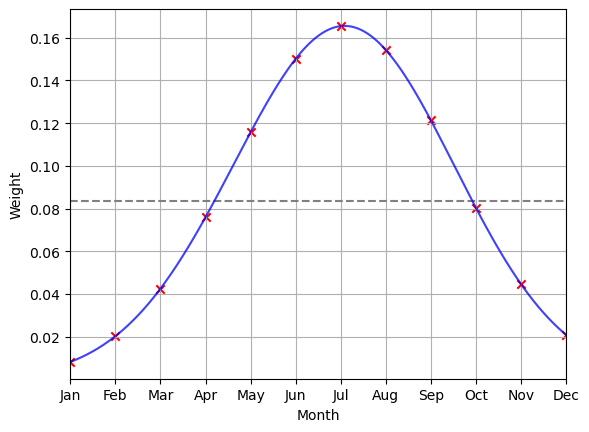

In [124]:

month_weights = skewed_gaussian_month_weights(mu=best_mu, sigma=best_sigma, skew=best_skew)
month_weights_fine = skewed_gaussian_month_weights(mu=best_mu, sigma=best_sigma, skew=best_skew, x=np.linspace(1, 13, 1000, endpoint=False))
#month_weights = np.ones(12) / 12  # Override with uniform weights for plotting
#month_weights = np.array([0,0,0,0,0,1,1,0,0,0,0,0]) / 3.0 # Override with idealised weights for plotting
plt.scatter(months, month_weights,  marker='x', color='red')
plt.plot(months, np.ones(12) / 12 ,  linestyle='--', color='gray')
plt.plot(np.linspace(0, 12, 1000, endpoint=False), month_weights_fine * month_weights.max() / month_weights_fine.max(), color='blue', alpha=0.75) 
plt.xlabel('Month')
plt.ylabel('Weight')
plt.xlim(0, 11)
plt.grid()
plt.show()

In [110]:
def plot_overall_regression(obs_energy=None, obs_sia=None, extra_model_energy=None, extra_model_sia=None, xlim=None, ylim=None):    
    anom_colors = ['red', 'green', 'blue', 'orange']
    model_markers = {
        'ACCESS-ESM1-5': 'x',
        'CESM2': 's',
        'IPSL-CM6A-LR': 'D',
        'MIROC-ES2L': '^',
        'NESM3': 'v',
        'MMM': '*',
    }




    energy_data_list = []
    sia_data_list = []

    fig, ax = plt.subplots(figsize=(10, 6))
    for big_dict, name, color in zip(anom_big_dict_list, anom_big_dict_names, anom_colors):
        for model in big_dict.keys():
            
                
            #print(np.sum(big_dict[model]['anom_clim']['total_energy']))
            #print(np.min(big_dict[model]['anom_clim']['siconc']))

            energy_data = np.dot(month_weights, big_dict[model]['anom_clim'][energy_for_analysis].data) 
            #energy_data = np.dot(month_weights, big_dict[model]['anom_clim']['rlds'].data) + best_sw_weight * np.dot(month_weights, big_dict[model]['anom_clim']['rsds'].data)
            #energy_data = np.max(big_dict[model]['anom_clim'][energy_for_analysis].data)
            sia_data = np.min(big_dict[model]['anom_clim']['siconc'].data) / 1e14
            
            
            
            if model == 'MMM':  # Exclude MMM  from the r2 analysis, but still plot it
                plt.scatter(
                    energy_data,
                    sia_data,
                    color=color,
                    marker=model_markers[model],
                    s=180,
                    edgecolor='black',
                    linewidth=1.2,
                    #label=f'{name} {model}',
                    zorder=5,
                )
            else:
                plt.scatter(
                    energy_data, 
                    sia_data, 
                    color=color, 
                    marker=model_markers[model], 
                    #label=f'{name} {model}',
                    )
                energy_data_list.append(energy_data)
                sia_data_list.append(sia_data)

    #get linear fit for the data
    coefficients = np.polyfit(energy_data_list, sia_data_list, 1)
    linear_fit = np.poly1d(coefficients)
    x_fit = np.linspace(min(min(energy_data_list), 0), max(energy_data_list), 100)
    y_fit = linear_fit(x_fit)
    slope = coefficients[0]
    intercept = coefficients[1]

    fix_intercept = False
    if fix_intercept:
        slope = np.dot(energy_data_list, sia_data_list) / np.dot(energy_data_list, energy_data_list)
        intercept = 0.0
        y_fit = slope * x_fit

    if obs_energy is not None and obs_sia is not None:
        plt.scatter(obs_energy,obs_sia, marker='o', s=2.5,label='Observations', color='black')

        r2_obs = np.corrcoef(obs_energy, obs_sia)[0, 1] ** 2

    if extra_model_energy is not None and extra_model_sia is not None:
        plt.scatter(extra_model_energy, extra_model_sia, marker='X', s=100, label='Extra Model', color='purple')
        r2_extra = np.corrcoef(extra_model_energy, extra_model_sia)[0, 1] ** 2

    plt.plot(x_fit, y_fit, color='black', linestyle='--', label='Linear Fit')
    plt.xlabel('Weighted Energy Budget Anomaly (W/m²)')
    plt.ylabel('Minimum SIA Anomaly (million km²)')
    plt.title('Weighted Energy Budget Anomaly vs Minimum SIA Anomaly')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
    #put legend outside of plot
    #plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    if xlim is not None:
        plt.xlim(xlim)
    else:
        plt.xlim(0, max(energy_data_list) * 1.1)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid()

    # ------------------------------------------------------------------
    # Custom legends
    # ------------------------------------------------------------------

    # Shape legend: one marker per model
    shape_handles = []

    for model, marker in model_markers.items():
        if model == 'MMM':
            handle = Line2D(
                [0], [0],
                marker=marker,
                color='none',
                markerfacecolor='grey',
                markeredgecolor='black',
                markeredgewidth=1.2,
                markersize=14,
                linestyle='None',
                label=model
            )
        else:
            handle = Line2D(
                [0], [0],
                marker=marker,
                color='grey',
                markerfacecolor='grey',
                markeredgecolor='grey',
                markersize=8,
                linestyle='None',
                label=model
            )

        shape_handles.append(handle)

    # Colour legend: one colour per anomaly set
    colour_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor=color,
            markeredgecolor='black',
            markersize=8,
            linestyle='None',
            label=name
        )
        for name, color in zip(anom_big_dict_names, anom_colors)
    ]

    # Regression legend
    line_handles = [
        Line2D(
            [0], [0],
            color='black',
            linestyle='--',
            label='Linear fit'
        )
    ]

    # First legend: model shapes
    legend1 = ax.legend(
        handles=shape_handles,
        title='Model',
        loc='center left',
        bbox_to_anchor=(1.02, 0.70),
        frameon=False
    )

    # Add first legend manually so it is not overwritten
    ax.add_artist(legend1)

    # Second legend: colours
    legend2 = ax.legend(
        handles=colour_handles + line_handles,
        title='Experiment',
        loc='center left',
        bbox_to_anchor=(1.02, 0.30),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    r2 = np.corrcoef(energy_data_list, sia_data_list)[0, 1] ** 2

    print(f'R² between energy data and SIA data: {r2:.3f}')
    print(f'Linear regression coefficients: slope = {slope:.3f}, intercept = {intercept:.3f}')
    if obs_energy is not None and obs_sia is not None:
        print(f'R² between weighted energy data and observed SIA anomaly: {r2_obs:.3f}')

    if extra_model_energy is not None and extra_model_sia is not None:
        print(f'R² between weighted energy data and extra model SIA anomaly: {r2_extra:.3f}')

    return slope, intercept, r2


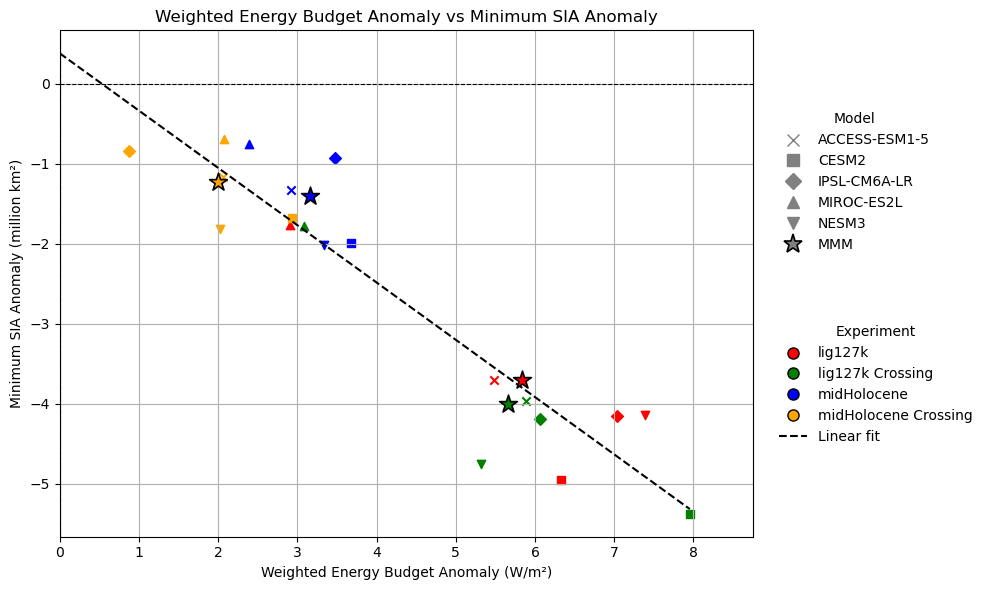

R² between energy data and SIA data: 0.868
Linear regression coefficients: slope = -0.717, intercept = 0.382


In [55]:
slope, intercept, r2 = plot_overall_regression()

In [36]:
#break_the_code = MAKE_NEW_CODE_OF_VIOLIN_PLOTS_TO_STUDY_SIA_VARIABILITY

In [37]:
obs_energy = 'ERA5'

rad_file = "era5_arctic_downwelling_radiation_monthly_1950-2025.nc"
net_file = "era5_arctic_net_energy_flux_monthly_1950-2025.nc"
turb_file = "era5_arctic_turbulent_energy_flux_monthly_1950-2025.nc"
tos_file = "era5_arctic_sst_monthly_1950-2025.nc"
lsm_file = "era5_arctic_land_sea_mask_monthly_1950.nc"

rad_cubes = iris.load(root_path + obs_energy + '/' + rad_file)
rlds = rad_cubes.extract_cube(
    iris.Constraint(name="Surface long-wave (thermal) radiation downwards")
)

rsds = rad_cubes.extract_cube(
    iris.Constraint(name="surface_downwelling_shortwave_flux_in_air")
)

net_cubes = iris.load(root_path + obs_energy + '/' + net_file)
swnet = net_cubes.extract_cube(
    iris.Constraint(name="surface_net_downward_shortwave_flux")
)
lwnet = net_cubes.extract_cube(
    iris.Constraint(name="surface_net_upward_longwave_flux")
)

turb_cubes = iris.load(root_path + obs_energy + '/' + turb_file)
hfls = turb_cubes.extract_cube(
    iris.Constraint(name="surface_upward_latent_heat_flux")
)
hfss = turb_cubes.extract_cube(
    iris.Constraint(name="surface_upward_sensible_heat_flux")
)

tos_cubes = iris.load(root_path + obs_energy + '/' + tos_file)
tos = tos_cubes.extract_cube(
    iris.Constraint(name="Sea surface temperature")
)

In [38]:
seconds_in_day = 86400

rlds.rename("rlds")
rsds.rename("rsds")
swnet.rename("swnet")
lwnet.rename("lwnet")
hfls.rename("hfls")
hfss.rename("hfss")
tos.rename("tos")

rlds = rlds / seconds_in_day
rsds = rsds / seconds_in_day
swnet = swnet / seconds_in_day
lwnet = lwnet / seconds_in_day
hfls = hfls / seconds_in_day
hfss = hfss / seconds_in_day

rlds.units = "W m-2"
rsds.units = "W m-2"
swnet.units = "W m-2"
lwnet.units = "W m-2"
hfls.units = "W m-2"
hfss.units = "W m-2"

In [39]:
def ensure_lat_lon_bounds(cube):
    """
    Add latitude/longitude bounds if missing.
    Clips latitude bounds to [-90, 90], which is important near the pole.
    """
    cube = cube.copy()

    lat = cube.coord("latitude")
    lon = cube.coord("longitude")

    if not lat.has_bounds():
        lat.guess_bounds()
        lat.bounds = np.clip(lat.bounds, -90, 90)

    if not lon.has_bounds():
        lon.guess_bounds()

    return cube

def add_year_month(cube):
    """
    Add numeric year and month_number coordinates.
    Also remove any string-valued auxiliary time coords, which can break Iris aggregated_by.
    """
    cube = cube.copy()

    time_dim = cube.coord_dims("time")[0]

    # Remove string auxiliary coords along time dimension
    for coord in list(cube.coords(dim_coords=False)):
        dims = cube.coord_dims(coord)
        if dims == (time_dim,) and coord.points.dtype.kind in ["U", "S", "O"]:
            cube.remove_coord(coord)

    if not cube.coords("year"):
        icc.add_year(cube, "time", name="year")

    if not cube.coords("month_number"):
        icc.add_month_number(cube, "time", name="month_number")

    return cube

In [40]:
rlds = ensure_lat_lon_bounds(rlds)
rsds = ensure_lat_lon_bounds(rsds)
swnet = ensure_lat_lon_bounds(swnet)
lwnet = ensure_lat_lon_bounds(lwnet)
hfls = ensure_lat_lon_bounds(hfls)
hfss = ensure_lat_lon_bounds(hfss)
tos = ensure_lat_lon_bounds(tos)

In [41]:
lsm = iris.load_cube(root_path + obs_energy + '/' + lsm_file)

ut_scale(): NULL factor argument
ut_are_convertible(): NULL unit argument


In [42]:
if lsm.ndim == 3:
    lsm_2d = lsm[0]
else:
    lsm_2d = lsm

In [43]:
ocean_fraction = 1 - lsm_2d.data

In [44]:
def ocean_mean_timeseries(cube, ocean_fraction):
    """
    Area-weighted mean over fractional ocean cells.
    Assumes cube dimensions include time, latitude, longitude.
    """

    cube = ensure_lat_lon_bounds(cube)

    lat_dim = cube.coord_dims("latitude")[0]
    lon_dim = cube.coord_dims("longitude")[0]

    # Area weights for full cube, same shape as cube
    area = iris.analysis.cartography.area_weights(cube)

    # Broadcast 2D ocean fraction to full cube shape
    ocean_weights = iris.util.broadcast_to_shape(
        ocean_fraction,
        cube.shape,
        (lat_dim, lon_dim)
    )

    weights = area * ocean_weights
    weights = np.ma.masked_invalid(weights)

    ts = cube.collapsed(
        ["latitude", "longitude"],
        iris.analysis.MEAN,
        weights=weights
    )

    ts.rename(f"{cube.name()}_ocean_mean")
    return ts

In [45]:
print('Calculating ocean mean timeseries for observational data...')
rlds_ocean_ts = ocean_mean_timeseries(rlds, ocean_fraction)
print('Done rlds')
rsds_ocean_ts = ocean_mean_timeseries(rsds, ocean_fraction)
print('Done rsds')
swnet_ocean_ts = ocean_mean_timeseries(swnet, ocean_fraction)
print('Done swnet')
lwnet_ocean_ts = ocean_mean_timeseries(lwnet, ocean_fraction)
print('Done lwnet')
hfls_ocean_ts = ocean_mean_timeseries(hfls, ocean_fraction)
print('Done hfls')
hfss_ocean_ts = ocean_mean_timeseries(hfss, ocean_fraction)
print('Done hfss')
tos_ocean_ts = ocean_mean_timeseries(tos, ocean_fraction)
print('Done tos')


Calculating ocean mean timeseries for observational data...


Done rlds
Done rsds
Done swnet
Done lwnet
Done hfls
Done hfss
Done tos


In [46]:

total_down_ocean_ts = rlds_ocean_ts + rsds_ocean_ts
total_down_ocean_ts.rename("rsds_plus_rlds_ocean_mean")
total_down_ocean_ts.units = "W m-2"

total_ocean_ts = swnet_ocean_ts + lwnet_ocean_ts + hfls_ocean_ts + hfss_ocean_ts
total_ocean_ts.rename("total_energy_ocean_mean")
total_ocean_ts.units = "W m-2"

In [47]:
start_year = 1979
end_year = start_year - 1 + 20


In [56]:

anom_first_then_clim = True
if anom_first_then_clim:
    # Subtract climatology first, then apply month weights to anomalies
    total_ocean_ts = add_year_month(total_ocean_ts)

    year_points = total_ocean_ts.coord("year").points
    month_points = total_ocean_ts.coord("month_number").points

    data = np.ma.array(total_ocean_ts.data, copy=True)

    baseline_mask = (year_points >= start_year) & (year_points <= end_year)

    monthly_clim = np.ma.array([
        data[baseline_mask & (month_points == month)].mean()
        for month in range(1, 13)
    ])
    total_ocean_ts_anom = total_ocean_ts.copy(data=total_ocean_ts.data - monthly_clim[month_points - 1])
    total_ocean_ts_anom.rename("total_energy_anomaly_ocean_mean")

    year_points = total_ocean_ts_anom.coord("year").points
    month_points = total_ocean_ts_anom.coord("month_number").points.astype(int)
    data = np.ma.array(total_ocean_ts_anom.data)

    unique_years = np.unique(year_points)

    weighted_yearly_data = []

    for year in unique_years:
        year_mask = year_points == year

        year_months = month_points[year_mask]
        year_data = data[year_mask]

        # Convert month number 1..12 to index 0..11
        year_weights = month_weights[year_months - 1]

        # Renormalise within each year, in case a year is incomplete
        year_weights = year_weights / year_weights.sum()

        weighted_mean = np.ma.sum(year_data * year_weights)

        weighted_yearly_data.append(weighted_mean)

    weighted_yearly_data = np.ma.array(weighted_yearly_data)
else:


    total_ocean_ts = add_year_month(total_ocean_ts)

    year_points = total_ocean_ts.coord("year").points
    month_points = total_ocean_ts.coord("month_number").points.astype(int)

    data = np.ma.array(total_ocean_ts.data, copy=True)

    month_weights = np.asarray(month_weights, dtype=float)
    month_weights = month_weights / month_weights.sum()

    unique_years = np.unique(year_points)

    weighted_yearly_energy = []

    for year in unique_years:
        year_mask = year_points == year

        year_months = month_points[year_mask]
        year_data = data[year_mask]

        # Get the weights corresponding to the months present in this year
        year_weights = month_weights[year_months - 1]

        # Renormalise in case the year is incomplete
        year_weights = year_weights / year_weights.sum()

        weighted_mean = np.ma.sum(year_data * year_weights)

        weighted_yearly_energy.append(weighted_mean)

    weighted_yearly_energy = np.ma.array(weighted_yearly_energy)

    baseline_year_mask = (unique_years >= start_year) & (unique_years <= end_year)

    weighted_energy_clim = weighted_yearly_energy[baseline_year_mask].mean()

    weighted_yearly_data = weighted_yearly_energy - weighted_energy_clim
    

In [57]:
#open csv file to get the sia anoms
import csv

obs_sia_source = 'NSIDC'
obs_sia_file = 'N_09_extent_v4.0.csv'

obs_years = []
obs_sia = []
with open(root_path + obs_sia_source + '/' + obs_sia_file, 'r') as f:
    reader = csv.reader(f)
    next(reader)  # skip header
    for row in reader:
        obs_years.append(int(row[0]))
        obs_sia.append(float(row[5]))

obs_sia_clim = np.mean([sia for year, sia in zip(obs_years, obs_sia) if start_year <= year <= end_year])

obs_sia_anom = np.array(obs_sia) - obs_sia_clim


In [58]:
obs_siv_source = 'PIOMASS'
obs_siv_file = 'PIOMASS_SIV_monthly.csv'

# Read CSV
df = pd.read_csv(root_path + obs_siv_source + '/' + obs_siv_file)


# Convert from wide format to long format
df_long = df.melt(
    id_vars="Year",
    value_vars=months,
    var_name="month",
    value_name="sea_ice_volume"
)

# Convert month names to month numbers
month_numbers = {m: i for i, m in enumerate(months, start=1)}
df_long["month_number"] = df_long["month"].map(month_numbers)

# Create datetime column
df_long["date"] = pd.to_datetime(
    dict(
        year=df_long["Year"],
        month=df_long["month_number"],
        day=15
    )
)

# Sort into true date order
df_long = df_long.sort_values("date").reset_index(drop=True)

# Optional: remove PIOMAS missing values if present
df_long["sea_ice_volume"] = df_long["sea_ice_volume"].replace(-1, np.nan)

# Final arrays
siv_dates = df_long["date"].to_numpy()
siv_ts = df_long["sea_ice_volume"].to_numpy()

growth_ts = np.diff(siv_ts)



In [59]:
def running_mean(data, window_size=10):
    running_mean = (
    pd.Series(data)
    .rolling(window=window_size, center=True)
    .mean()
    .to_numpy()
    )
    return running_mean

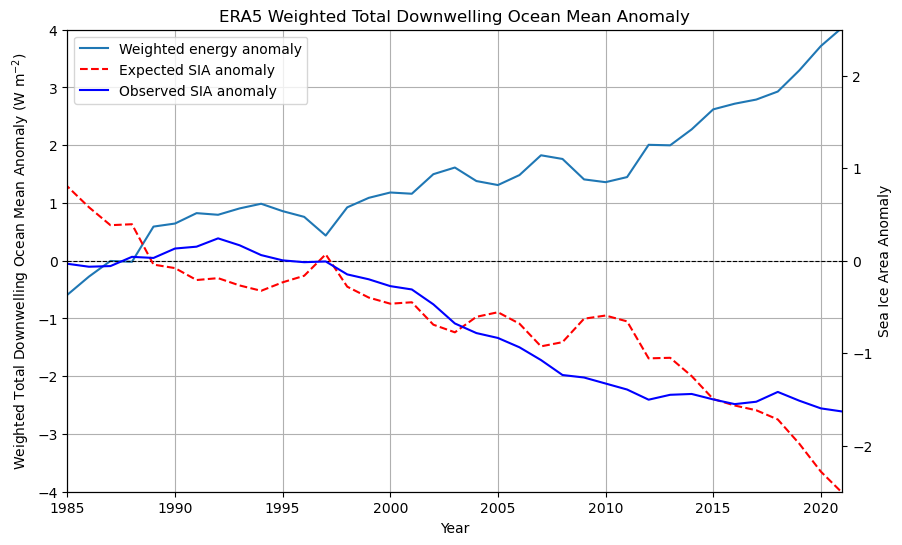

In [62]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: weighted energy anomaly
ax1.plot(
    unique_years,
    running_mean(weighted_yearly_data),
    label="Weighted energy anomaly"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Weighted Total Downwelling Ocean Mean Anomaly (W m$^{-2}$)")

ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax1.grid()

# Calculate expected SIA anomaly from weighted energy anomaly
weighted_rm = running_mean(weighted_yearly_data)
expected_sia_anom = slope * weighted_rm + intercept

# Right axis: SIA anomaly
ax2 = ax1.twinx()

ax2.plot(
    unique_years,
    expected_sia_anom,
    color="red",
    linestyle="--",
    label="Expected SIA anomaly"
)

ax2.plot(
    obs_years,
    running_mean(obs_sia_anom),
    color="blue",
    linestyle="-",
    label="Observed SIA anomaly"
)

ax1.set_xlim(1985, 2021)
ax2.set_ylabel("Sea Ice Area Anomaly")
ax2.set_ylim(-2.5,2.5)
ax1.set_ylim(-4,4)

# Combined legend from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("ERA5 Weighted Total Downwelling Ocean Mean Anomaly")
plt.show()

In [63]:
last_10 = weighted_yearly_data[-10:].mean()
print(f"Mean of last 10 years: {last_10:.5f} W/m²")
expected_sia_anom = slope * last_10 + intercept
print(f"Expected SIA anomaly from regression: {expected_sia_anom:.3f} million km²")

##With minus:
#Mean of last 10 years: 5.09584 W/m²
#Expected SIA anomaly from regression: -3.270 million km²

Mean of last 10 years: 4.03891 W/m²
Expected SIA anomaly from regression: -2.513 million km²


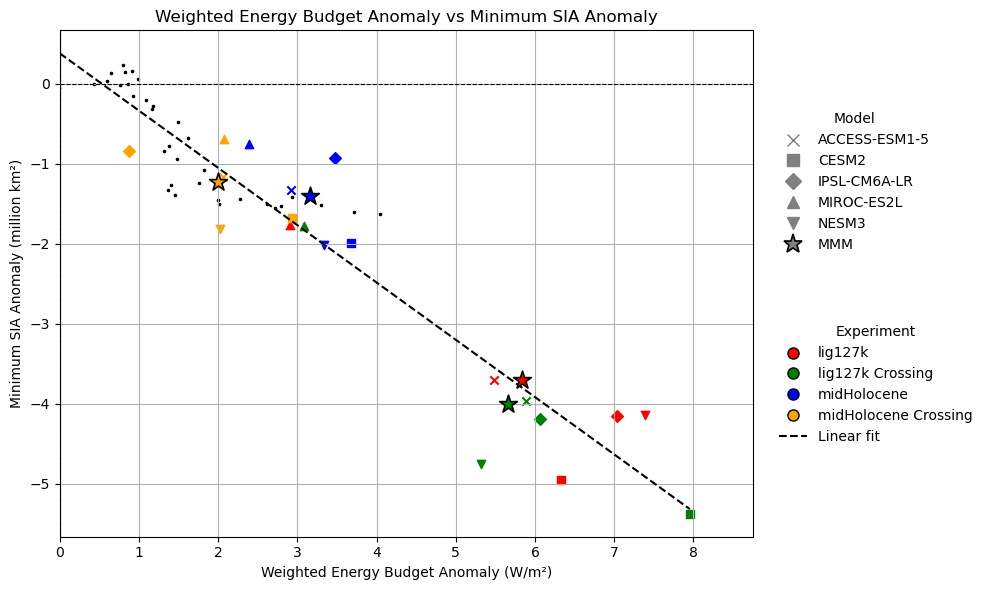

R² between energy data and SIA data: 0.868
Linear regression coefficients: slope = -0.717, intercept = 0.382
R² between weighted energy data and observed SIA anomaly: 0.690


In [64]:

_ = plot_overall_regression(obs_energy=running_mean(weighted_yearly_data)[-42:-4], obs_sia=running_mean(obs_sia_anom)[-42:-4])

In [103]:
#Now we are going to look at some models that only have lig127k runs so aren't part of the optimization
#Do they still fit on the regression?

month_weights = skewed_gaussian_month_weights(mu=best_mu, sigma=best_sigma, skew=best_skew)


test_models = ['EC-Earth3', 'EC-Earth3-LR', 'NorESM1-F']
sia_anom_array = []
weighted_energy_anom_array = []
for model in test_models:

    siconc_paleo_path = create_path(model, paleo, 'siconc', root_path, regrid_label = 'regrid')
    siconc_paleo_cube = get_cube(siconc_paleo_path, 'siconc', con, shape=shape)
    siconc_paleo_clim = get_monthly_data(siconc_paleo_cube, analysis = 'sum', second_analysis = 'mean')

    siconc_control_path = create_path(model, control, 'siconc', root_path, regrid_label = 'regrid')
    siconc_control_cube = get_cube(siconc_control_path, 'siconc', con, shape=shape)
    siconc_control_clim = get_monthly_data(siconc_control_cube, analysis = 'sum', second_analysis = 'mean') 

    siconc_anom_clim = np.min(siconc_paleo_clim) - np.min(siconc_control_clim)
    sia_anom = (siconc_anom_clim) / 1e14
    sia_anom_array.append(sia_anom)
    print(f"{model} SIA anomaly: {sia_anom:.3f} million km²")

    total_energy_anom_clim = np.zeros(12)
    for var in energy_vars:
        if var not in cloud_vars:
            paleo_cube = get_cube(
                create_path(model, paleo, var, root_path, regrid_label='regrid'),
                var,
                con,
                shape=shape
            )
            control_cube = get_cube(
                create_path(model, control, var, root_path, regrid_label='regrid'),
                var,
                con,
                shape=shape
            )

            paleo_clim = get_monthly_data(paleo_cube, analysis='mean')
            control_clim = get_monthly_data(control_cube, analysis='mean')

            energy_anom_clim = paleo_clim - control_clim

            total_energy_anom_clim += energy_anom_clim * energy_var_dict[var]

    weighted_energy_anom = np.dot(month_weights, total_energy_anom_clim)

    weighted_energy_anom_array.append(weighted_energy_anom)
    print(f"{model} Total weighted energy anomaly: {weighted_energy_anom:.3f} W/m²")


EC-Earth3 SIA anomaly: -5.601 million km²
EC-Earth3 Total weighted energy anomaly: 9.831 W/m²
EC-Earth3-LR SIA anomaly: -5.026 million km²
EC-Earth3-LR Total weighted energy anomaly: 9.442 W/m²
NorESM1-F SIA anomaly: -2.140 million km²
NorESM1-F Total weighted energy anomaly: 5.164 W/m²


In [90]:
#open csv file of hadgem data
hadgem_path = '/home/users/matt/'
hadgem_lig127k_file = 'hadgem3_lig127k_climatologies.csv'
hadgem_picontrol_file = 'hadgem3_piControl_climatologies.csv'

def extract_clim_array(df, var):
    clim_string = df.loc[df["Variable"] == var, "Climatology"].iloc[0]
    return np.fromstring(clim_string.strip("[]"), sep=" ")

In [ ]:
hadgem_lig127k_data = pd.read_csv(hadgem_path + hadgem_lig127k_file)
hadgem_picontrol_data = pd.read_csv(hadgem_path + hadgem_picontrol_file)

In [96]:

hadgem_total_lig127k = extract_clim_array(hadgem_lig127k_data, 'total')
hadgem_total_picontrol = extract_clim_array(hadgem_picontrol_data, 'total')
hadgem_total_anom_clim = hadgem_total_lig127k - hadgem_total_picontrol



In [105]:
hadgem_weighted_energy_anom = np.dot(month_weights, hadgem_total_anom_clim)
print(f"HadGEM3 LIG127k Total weighted energy anomaly: {hadgem_weighted_energy_anom:.3f} W/m²")


HadGEM3 LIG127k Total weighted energy anomaly: 10.159 W/m²


In [106]:
hadgem_sia_anom_value = np.min(extract_clim_array(hadgem_lig127k_data, 'siconc')) - np.min(extract_clim_array(hadgem_picontrol_data, 'siconc'))
#hadgem_sia_anom_value = np.min(hadgem_sia_anom) 
print(f"HadGEM3 LIG127k SIA anomaly: {hadgem_sia_anom_value:.3f} million km²")

HadGEM3 LIG127k SIA anomaly: -5.382 million km²


In [108]:
sia_anom_array.append(hadgem_sia_anom_value)
weighted_energy_anom_array.append(hadgem_weighted_energy_anom)

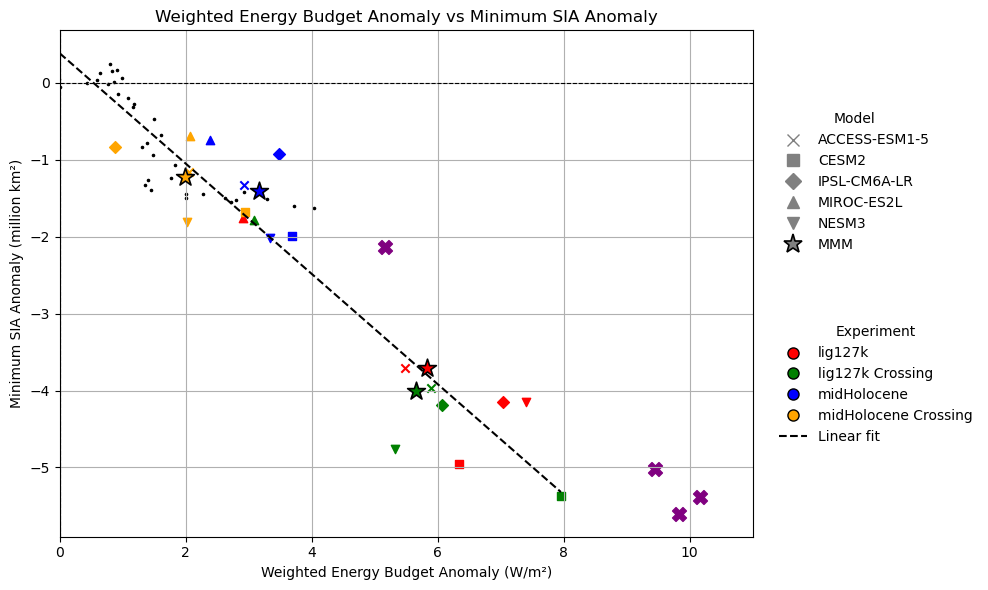

R² between energy data and SIA data: 0.868
Linear regression coefficients: slope = -0.717, intercept = 0.382
R² between weighted energy data and observed SIA anomaly: 0.690
R² between weighted energy data and extra model SIA anomaly: 0.987


In [111]:
_ = plot_overall_regression(obs_energy=running_mean(weighted_yearly_data)[-42:-4], obs_sia=running_mean(obs_sia_anom)[-42:-4], 
                            extra_model_energy=weighted_energy_anom_array, extra_model_sia=sia_anom_array,
                            xlim=(0,11))

In [ ]:
def plot_model_obs(obs_ts, model_var, start_year, end_year, ylabel=None, month_weights=None):
    plt.figure(figsize=(10,6))
    var_ts = obs_ts
    # get climatology from start year to end year
    var_ts = add_coords(var_ts)
    year_points = var_ts.coord("year").points
    month_points = var_ts.coord("month_number").points.astype(int)

    data = np.ma.array(var_ts.data, copy=True)

    baseline_mask = (year_points >= start_year) & (year_points <= end_year)

    var_control_clim = np.ma.array([
        data[baseline_mask & (month_points == month)].mean()
        for month in range(1, 13)
    ])

    end_mask = (year_points >= max(year_points) - 10) 
    var_end_clim = np.ma.array([
        data[end_mask & (month_points == month)].mean()
        for month in range(1, 13)
    ])

    var_end_anom = var_end_clim - var_control_clim
    if month_weights is None:
        month_weights = np.ones(12) / 12

    plt.plot(months, 12 * month_weights * paleo_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo}')
    plt.plot(months, 12 * month_weights * crossing_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo} Crossing')
    plt.plot(months, 12 * month_weights * paleo2_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo2}')
    plt.plot(months, 12 * month_weights * crossing2_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo2} Crossing')
    plt.plot(months, 12 * month_weights * var_end_anom, label = 'ERA5', color='black', linestyle='--')
    plt.xticks(np.arange(12), months)
    plt.xlabel('Month')
    if ylabel is None:
        ylabel = f'{model_var} Anomaly'
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0, 11)
    plt.legend()
    plt.show()


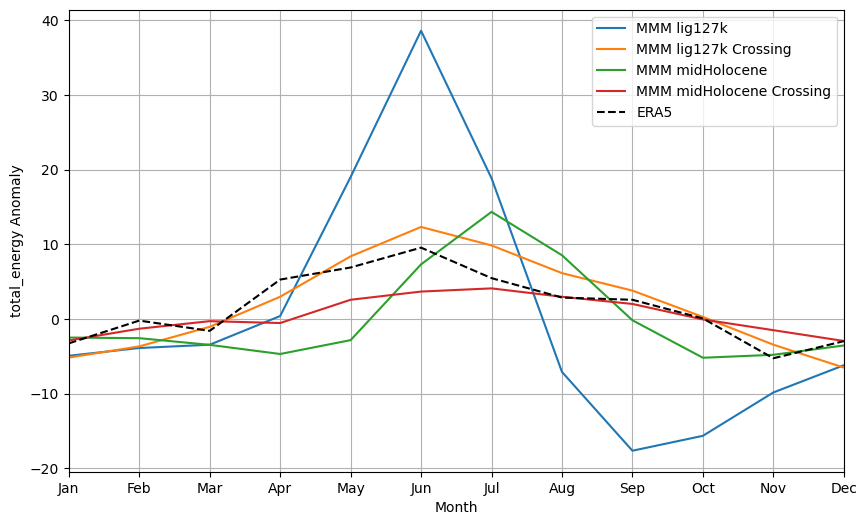

In [66]:

plot_model_obs(total_ocean_ts, 'total_energy', start_year, end_year)

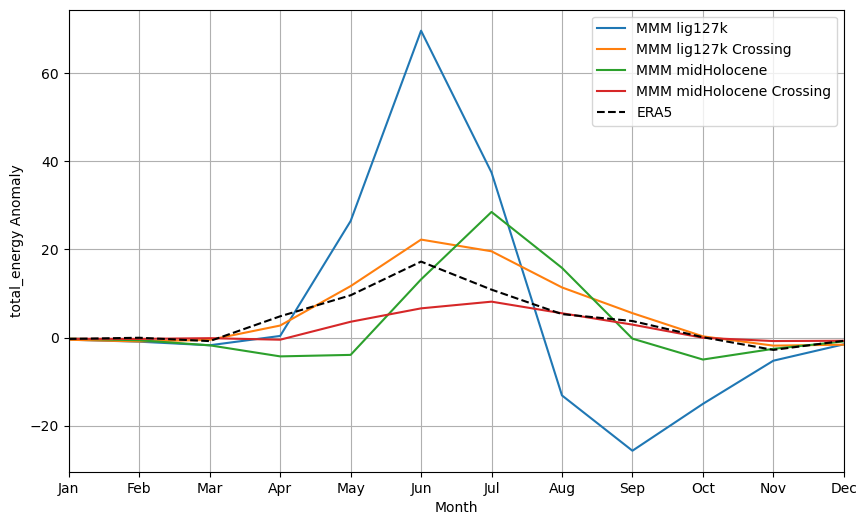

In [67]:
plot_model_obs(total_ocean_ts, 'total_energy', start_year, end_year, month_weights=month_weights)

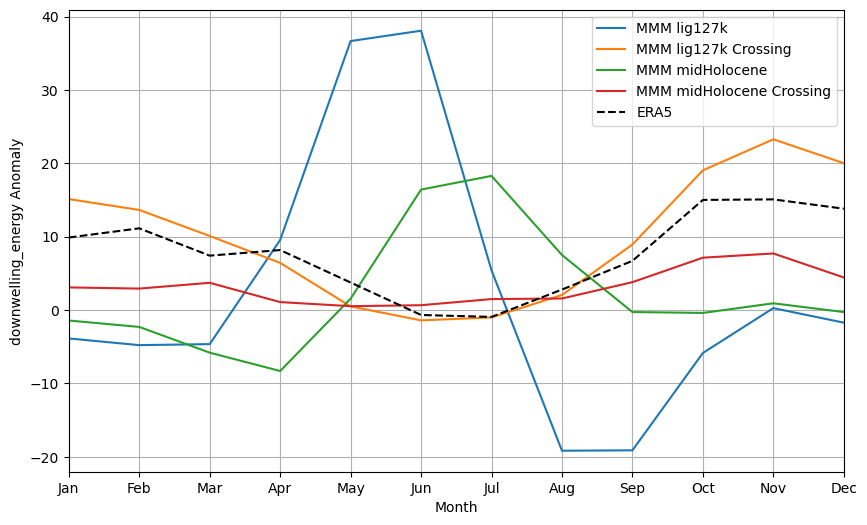

In [68]:
plot_model_obs(total_down_ocean_ts, 'downwelling_energy', start_year, end_year)

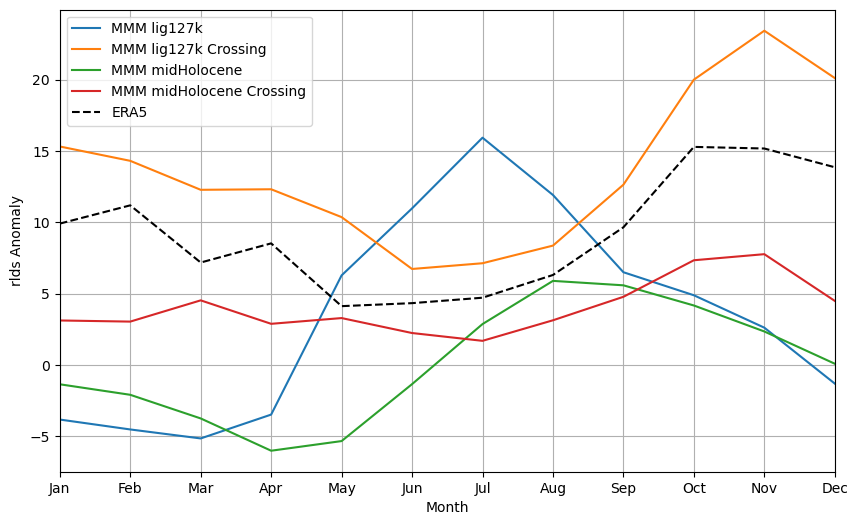

In [69]:
plot_model_obs(rlds_ocean_ts, 'rlds', start_year, end_year)

In [70]:
obs_sia_clim = np.mean([sia for year, sia in zip(obs_years, obs_sia) if start_year <= year <= end_year])
obs_sia_anom = np.array(obs_sia) - obs_sia_clim

In [71]:

model_var = 'siconc'
plt.figure(figsize=(10,6))
var_ts = obs_sia_anom
# get climatology from start year to end year
var_ts = add_coords(var_ts)
year_points = var_ts.coord("year").points
month_points = var_ts.coord("month_number").points.astype(int)

data = np.ma.array(var_ts.data, copy=True)

baseline_mask = (year_points >= start_year) & (year_points <= end_year)

var_control_clim = np.ma.array([
    data[baseline_mask & (month_points == month)].mean()
    for month in range(1, 13)
])

end_mask = (year_points >= max(year_points) - 10) 
var_end_clim = np.ma.array([
    data[end_mask & (month_points == month)].mean()
    for month in range(1, 13)
])

var_end_anom = var_end_clim - var_control_clim
if month_weights is None:
    month_weights = np.ones(12) / 12

plt.plot(months, 12 * month_weights * paleo_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo}')
plt.plot(months, 12 * month_weights * crossing_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo} Crossing')
plt.plot(months, 12 * month_weights * paleo2_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo2}')
plt.plot(months, 12 * month_weights * crossing2_big_dict['MMM']['anom_clim'][model_var], label=f'MMM {paleo2} Crossing')
plt.plot(months, 12 * month_weights * var_end_anom, label = 'ERA5', color='black', linestyle='--')
plt.xticks(np.arange(12), months)
plt.xlabel('Month')
if ylabel is None:
    ylabel = f'{model_var} Anomaly'
plt.ylabel(ylabel)
plt.grid()
plt.xlim(0, 11)
plt.legend()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'coord'

<Figure size 1000x600 with 0 Axes>

In [ ]:
for var in control_big_dict[model]['clim'].keys():
    print(var)

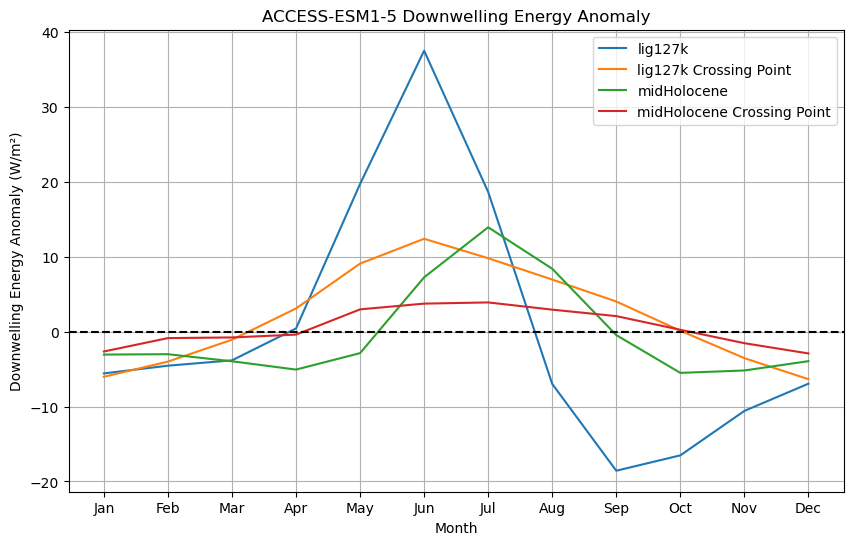

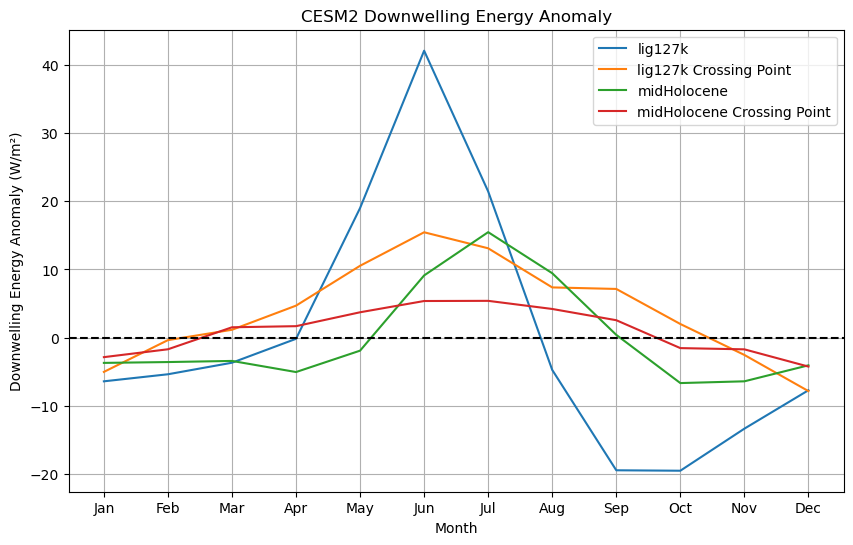

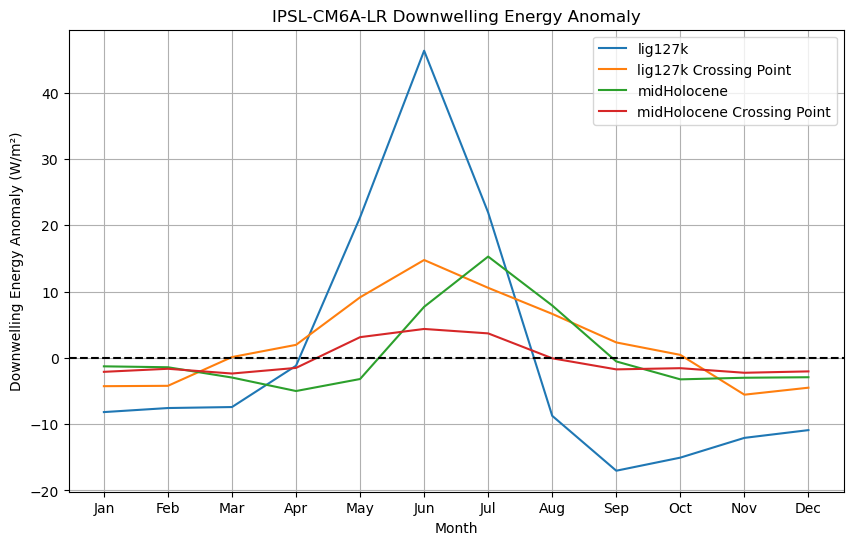

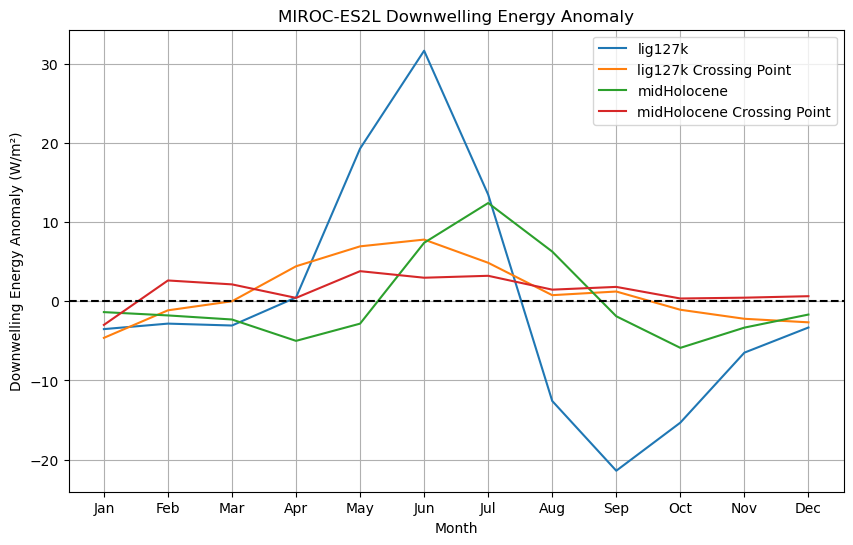

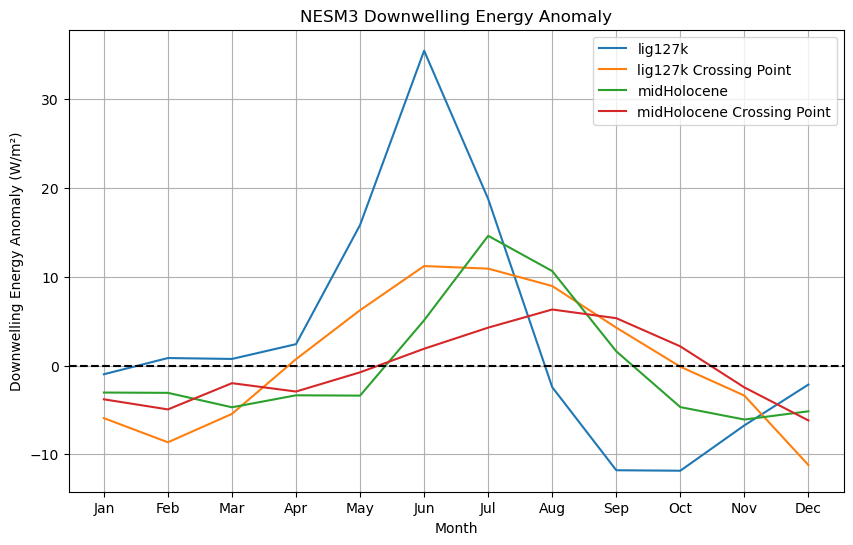

In [ ]:
for model in models:
    plot_all_periods(
        model,
        var='total_energy',
        var_type='anom_clim',
        title='Downwelling Energy Anomaly',
        ylabel='Downwelling Energy Anomaly (W/m²)'
)

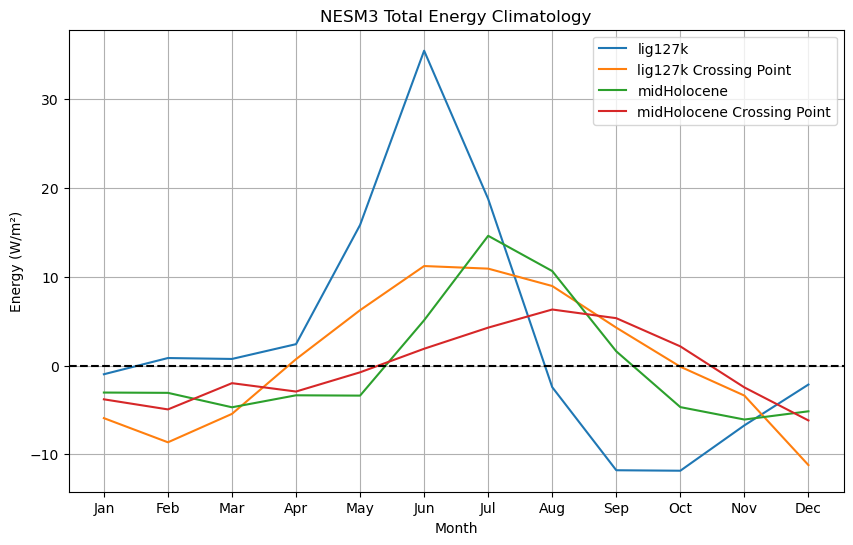

In [ ]:
plot_all_periods(
    model,
    var='total_energy',
    var_type='anom_clim',
    title='Total Energy Climatology',
    ylabel='Energy (W/m²)'
)

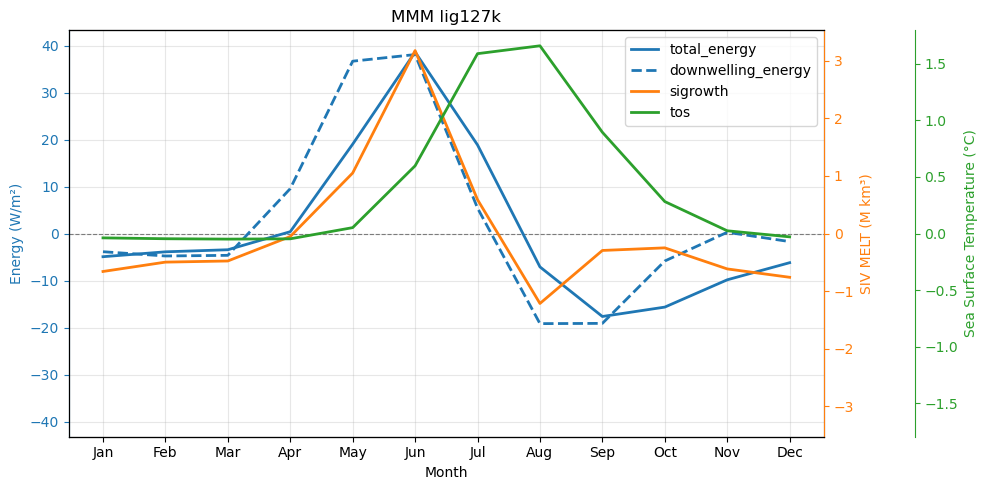

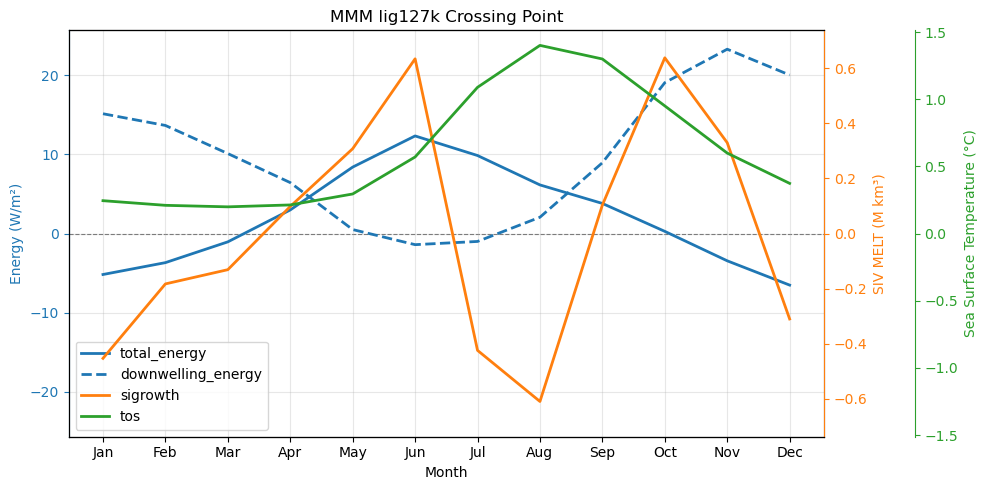

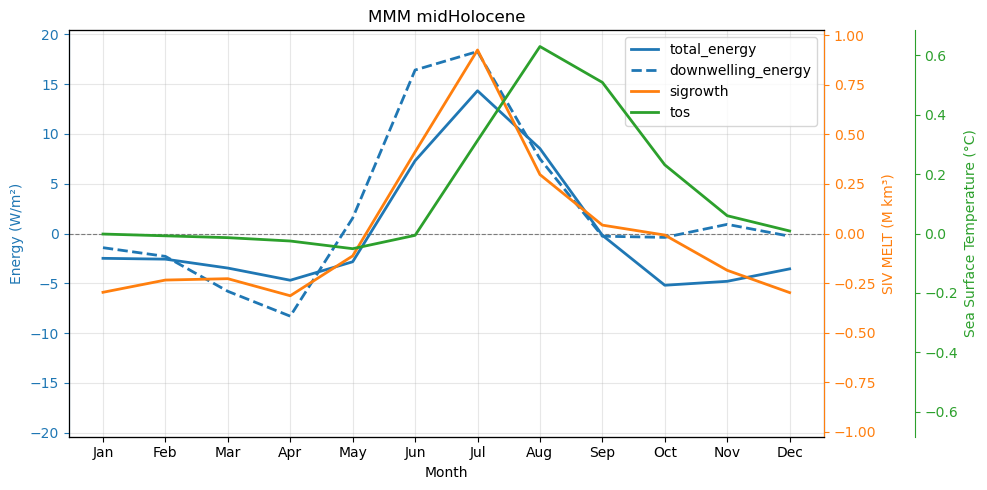

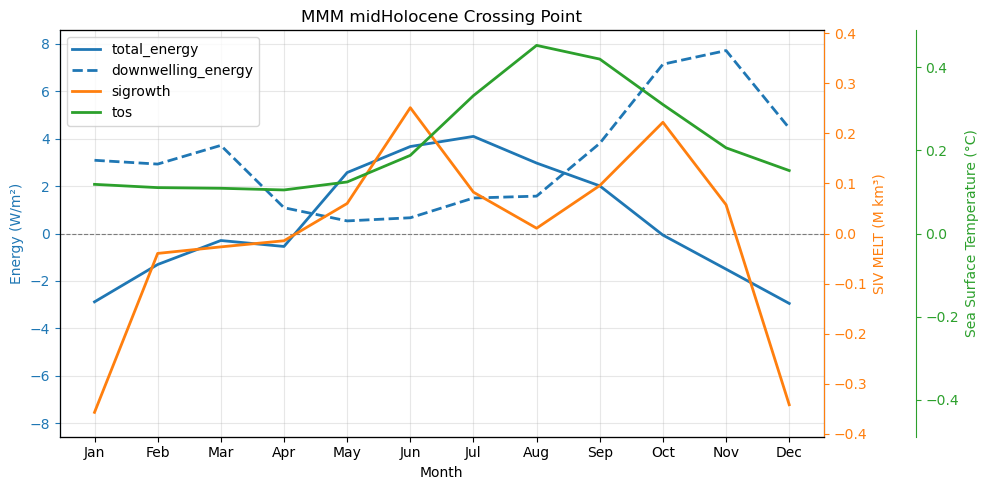

In [ ]:
model='MMM'

plot_var_list = ['total_energy', 'downwelling_energy', 'sigrowth','tos']
plot_labels_list = ['Energy (W/m²)', 'Downward Radiation (W/m²)', 'SIV MELT (M km³)', 'Sea Surface Temperature (°C)']
plot_ax_list = [1,1,2,3]
plot_factor_list = [1, 1, -1/1e12, 1] #convert sigrowth from m³/month to million km³/month

plot_one_period(paleo_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo, plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list = plot_factor_list)
plot_one_period(crossing_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo + ' Crossing Point', plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list = plot_factor_list)

plot_one_period(paleo2_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo2, plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list=plot_factor_list)
plot_one_period(crossing2_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo2 + ' Crossing Point', plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list = plot_factor_list)

In [ ]:
plot_var_list = ['total_energy', 'clt', 'lw_cloudeffect', 'sw_cloudeffect','total_cloudeffect']
plot_labels_list = ['Energy (W/m²)', 'Cloud Cover)', 'LW Cloudeffect (Pct Clearsky)','SW Cloudeffect (Pct Clearsky)', 'Total Cloudeffect (W/m²)']
plot_ax_list = [1,2,3,3,4]
plot_factor_list = [1, 1, 1,1, 1] #convert sigrowth from m³/month to million km³/month
plot_one_period(paleo_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo, plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list = plot_factor_list)
plot_one_period(crossing_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo + ' Crossing Point', plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list = plot_factor_list)

plot_one_period(paleo2_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo2, plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list=plot_factor_list)
plot_one_period(crossing2_big_dict, model, plot_var_list, var_type='anom_clim', title=paleo2 + ' Crossing Point', plot_ax_list=plot_ax_list, ylabel_list=plot_labels_list, plot_factor_list = plot_factor_list)


In [ ]:
def convert_sigrowth_to_energy(model_dict, si_density = 917, Lo = 334000, t_seconds = 60 * 60 * 24 * 30):
    """
    Convert sea ice growth from volume per month to energy per month per unit area.

    Parameters:
        sigrowth_clim (array-like): Monthly mean sea ice growth in volume (e.g. km³/month)
    """

    area = model_dict['area'] #in m2

    sigrowth_clim = model_dict['anom_clim']['sigrowth'].data #in m3 per month


    sigrowth_energy_clim = -1 * sigrowth_clim * si_density * Lo /t_seconds / area #convert from volume growth in km3/month to energy in W/m²

    return sigrowth_energy_clim

In [ ]:
for model in models:
    paleo_growth_energy = convert_sigrowth_to_energy(paleo_big_dict[model])
    crossing_growth_energy = convert_sigrowth_to_energy(crossing_big_dict[model])
    paleo2_growth_energy = convert_sigrowth_to_energy(paleo2_big_dict[model])
    crossing2_growth_energy = convert_sigrowth_to_energy(crossing2_big_dict[model])
    plt.figure(figsize=(10,6))
    plt.plot(paleo_growth_energy, label=f'{paleo} Growth Energy')
    plt.plot(crossing_growth_energy, label=f'{paleo} Crossing Point Growth Energy')
    if paleo2:
        plt.plot(paleo2_growth_energy, label=f'{paleo2} Growth Energy')
        plt.plot(crossing2_growth_energy, label=f'{paleo2} Crossing Point Growth Energy')
    plt.xticks(np.arange(12), months)
    plt.xlabel('Month')
    plt.ylabel('Energy (W/m²)')
    plt.title(f'{model} Sea Ice Growth Energy Climatology')
    plt.grid()
    plt.axhline(0, color='black', linestyle='--')
    plt.legend()
    plt.show()


In [ ]:
break_here = asojn

In [ ]:
for model in models:
    plot_all_periods(model, 'clt', var_type='anom_clim', title='Cloud Fraction Anomaly Climatology', ylabel='Cloud Fraction Anomaly')

In [ ]:
for model in models:
    plot_all_periods(model, 'sivol', var_type='anom_clim', title='Sea Ice Volume Anomaly Climatology', ylabel='Sea Ice Volume Anomaly (km³)')

In [ ]:
for model in models:
    plot_all_periods(model, 'sigrowth', var_type='anom_clim', title='Sea Ice Growth Anomaly Climatology', ylabel='Sea Ice Growth Anomaly (km³/month)')

In [ ]:
for model in models:
    plot_all_periods(model, 'tos', var_type='anom_clim', title='SST Anomaly Climatology', ylabel='SST Anomaly (°C)')

In [ ]:
for model in models:
    plot_all_periods(model, 'rsds', second_var = 'rlds', operation = 'add', var_type='anom_clim', title='SW Downwelling Anomaly Climatology', ylabel='SW Downwelling Anomaly (W/m²)')

In [ ]:
for model in models:
    plot_all_periods(model, 'rlds', var_type='anom_clim', title='LW Downwelling Anomaly Climatology', ylabel='LW Downwelling Anomaly (W/m²)')

In [ ]:
for model in models:
    plot_all_periods(model, 'total_cloudeffect', var_type='clim', title='Total Cloud Effect Climatology', ylabel='Total Cloud Effect (W/m²)')
    plot_all_periods(model, 'sw_cloudeffect', var_type='clim', title='SW Cloud Effect Climatology', ylabel='SW Cloud Effect (Pct of Clear Sky)')
    plot_all_periods(model, 'lw_cloudeffect', var_type='clim', title='LW Cloud Effect Climatology', ylabel='LW Cloud Effect (Pct of Clear Sky)')

In [ ]:
for model in models:
    plot_all_periods(model, 'clt', var_type='anom_clim', title='Cloud Fraction Anomaly Climatology', ylabel='Cloud Fraction Anomaly')
    plot_all_periods(model, 'total_cloudeffect', var_type='anom_clim', title='Total Cloud Effect Climatology', ylabel='Total Cloud Effect (W/m²)')
    plot_all_periods(model, 'sw_cloudeffect', var_type='anom_clim', title='SW Cloud Effect Climatology', ylabel='SW Cloud Effect (Pct of Clear Sky)')
    plot_all_periods(model, 'lw_cloudeffect', var_type='anom_clim', title='LW Cloud Effect Climatology', ylabel='LW Cloud Effect (Pct of Clear Sky)')

In [ ]:
period = 20  # years per chunk
plot_anomalies = True  # if True, cloud diagnostics are shown as anomalies from control climatology


def add_total_energy(plot_dict, energy_vars, total_name='total_energy'):
    """
    Return a copy of plot_dict with total_energy added.
    total_energy = sum(plot_dict[var] for var in energy_vars)
    """
    out = {var: plot_dict[var] for var in energy_vars}

    total_cube = plot_dict[energy_vars[0]].copy()
    total_data = np.zeros_like(plot_dict[energy_vars[0]].data)

    for var in energy_vars:
        if var not in cloud_vars:
            total_data += plot_dict[var].data

    total_cube.data = total_data
    out[total_name] = total_cube

    return out


def make_cloud_effect_dict(ts_dict):
    """
    Calculate cloud-effect diagnostics from absolute fluxes.

    SW and LW terms are dimensionless ratios relative to clear sky.
    Total term is absolute cloud radiative effect in W m-2.
    """
    rsds = ts_dict['rsds']
    rlds = ts_dict['rlds']
    rsdscs = ts_dict['rsdscs']
    rldscs = ts_dict['rldscs']

    sw_cloudeffect = rsds.copy()
    sw_cloudeffect.data = (rsds.data - rsdscs.data) / rsdscs.data

    lw_cloudeffect = rlds.copy()
    lw_cloudeffect.data = (rlds.data - rldscs.data) / rldscs.data

    total_cloudeffect = rsds.copy()
    total_cloudeffect.data = (
        (rsds.data - rsdscs.data)
        + (rlds.data - rldscs.data)
    )

    return {
        'sw_cloudeffect': sw_cloudeffect,
        'lw_cloudeffect': lw_cloudeffect,
        'total_cloudeffect_wm2': total_cloudeffect,
    }


def subtract_control_monthly_climatology(cube, control_clim):
    """
    Convert a diagnostic time series into anomalies relative to the
    control monthly climatology.
    """
    out = cube.copy()
    out_data = np.ma.array(cube.data, copy=True)

    cube_months = cube.coord('month').points
    clim_months = control_clim.coord('month').points

    for month in np.unique(cube_months):
        clim_val = control_clim[clim_months == month].data
        out_data[cube_months == month] = cube.data[cube_months == month] - clim_val

    out.data = out_data
    return out


def make_cloud_plot_dict(exp_ts_dict, control_ts_dict=None, plot_anomalies=True):
    """
    Make cloud-effect plotting dictionary.

    If plot_anomalies=True, cloud diagnostics are calculated from absolute
    fluxes first, then converted to anomalies relative to the control
    monthly climatology.
    """
    cloud_dict = make_cloud_effect_dict(exp_ts_dict)

    if not plot_anomalies:
        return cloud_dict

    if control_ts_dict is None:
        raise ValueError("control_ts_dict must be provided when plot_anomalies=True")

    control_cloud_dict = make_cloud_effect_dict(control_ts_dict)

    out = {}

    for var, cube in cloud_dict.items():
        control_clim = control_cloud_dict[var].aggregated_by('month', iris.analysis.MEAN)
        out[var] = subtract_control_monthly_climatology(cube, control_clim)

    return out



# For your SIA-style siconc time series, this converts percent*m2 to million km2.
# If your siconc is already a concentration/fraction, set this to 1.0.
scale_map = {
    'tos': 1.0,
    'siconc': 1 / 1e14,
    'sivol': 1 / 1e9,
    'sigrowth': 1 / 1e9,
}

state_vars = scale_map.keys()

def add_state_vars(plot_dict, ts_dict, state_vars, scale_map=None):
    """
    Add non-energy state variables, e.g. tos and siconc, to the plot dictionary.
    """
    out = dict(plot_dict)

    if scale_map is None:
        scale_map = {}

    for var in state_vars:
        if var not in ts_dict:
            print(f"Skipping {var}: not found")
            continue

        cube = ts_dict[var].copy()
        scale = scale_map.get(var, 1.0)

        if scale != 1.0:
            cube.data = cube.data * scale

        out[var] = cube

    return out

In [ ]:
for model in models:

    # Energy anomalies can come from anom_ts
    ts_dict = transient_big_dict[model]['anom_ts']
    paleo_ts_dict = paleo_big_dict[model]['anom_ts']

    # Cloud diagnostics must come from absolute ts
    raw_ts_dict = transient_big_dict[model]['ts']
    raw_paleo_ts_dict = paleo_big_dict[model]['ts']
    raw_control_ts_dict = control_big_dict[model]['ts']

    if paleo2 is not None:
        paleo2_ts_dict = paleo2_big_dict[model]['anom_ts']
        raw_paleo2_ts_dict = paleo2_big_dict[model]['ts']
    else:
        paleo2_ts_dict = None
        raw_paleo2_ts_dict = None

    # -----------------------------
    # Energy variables + total energy
    # -----------------------------
    transient_plot_dict = add_total_energy(ts_dict, energy_vars)
    paleo_plot_dict = add_total_energy(paleo_ts_dict, energy_vars)

    if paleo2_ts_dict is not None:
        paleo2_plot_dict = add_total_energy(paleo2_ts_dict, energy_vars)
    else:
        paleo2_plot_dict = None

    # -----------------------------
    # Add tos and siconc
    # -----------------------------
    transient_plot_dict = add_state_vars(
        transient_plot_dict,
        ts_dict,
        state_vars,
        scale_map=scale_map
    )

    paleo_plot_dict = add_state_vars(
        paleo_plot_dict,
        paleo_ts_dict,
        state_vars,
        scale_map=scale_map
    )

    if paleo2_plot_dict is not None:
        paleo2_plot_dict = add_state_vars(
            paleo2_plot_dict,
            paleo2_ts_dict,
            state_vars,
            scale_map=scale_map
        )
    # -----------------------------
    # Cloud-effect diagnostics
    # -----------------------------
    transient_cloud_dict = make_cloud_plot_dict(
        raw_ts_dict,
        control_ts_dict=raw_control_ts_dict,
        plot_anomalies=plot_anomalies
    )

    paleo_cloud_dict = make_cloud_plot_dict(
        raw_paleo_ts_dict,
        control_ts_dict=raw_control_ts_dict,
        plot_anomalies=plot_anomalies
    )

    if raw_paleo2_ts_dict is not None:
        paleo2_cloud_dict = make_cloud_plot_dict(
            raw_paleo2_ts_dict,
            control_ts_dict=raw_control_ts_dict,
            plot_anomalies=plot_anomalies
        )
    else:
        paleo2_cloud_dict = None

    # Add cloud diagnostics to the plotting dictionaries
    transient_plot_dict.update(transient_cloud_dict)
    paleo_plot_dict.update(paleo_cloud_dict)

    if paleo2_plot_dict is not None and paleo2_cloud_dict is not None:
        paleo2_plot_dict.update(paleo2_cloud_dict)

    # -----------------------------
    # Plot everything
    # -----------------------------
    for var, transient_cube in transient_plot_dict.items():

        n_months = transient_cube.shape[0]
        n_years_available = n_months // 12

        plt.figure(figsize=(10, 6))

        # 1pctCO2 20-year chunks
        for start_year in range(0, n_years_available, period):
            end_year = min(start_year + period, n_years_available)

            if end_year - start_year < period:
                continue

            start_idx = 12 * start_year
            end_idx = 12 * end_year

            ts_chunk = transient_cube[start_idx:end_idx]
            clim_chunk = ts_chunk.aggregated_by('month', iris.analysis.MEAN)

            plt.plot(
                clim_chunk.data,
                label=f'1pctCO2 years {start_year + 1}-{end_year}',
                linestyle='-'
            )

        # Paleo climatology
        paleo_cube = paleo_plot_dict[var]
        paleo_clim = paleo_cube.aggregated_by('month', iris.analysis.MEAN)

        plt.plot(
            paleo_clim.data,
            label=f'{paleo}',
            linestyle='--',
            linewidth=2.5
        )

        # Paleo2 climatology
        if paleo2_plot_dict is not None and var in paleo2_plot_dict:
            paleo2_cube = paleo2_plot_dict[var]
            paleo2_clim = paleo2_cube.aggregated_by('month', iris.analysis.MEAN)

            plt.plot(
                paleo2_clim.data,
                label=f'{paleo2}',
                linestyle=':',
                linewidth=2.5
            )

        # -----------------------------
        # Labels
        # -----------------------------
        plt.xticks(np.arange(12), months)
        plt.xlabel('Month')

        if var in ['sw_cloudeffect', 'lw_cloudeffect']:
            ylabel = 'Cloud effect anomaly'
        elif var == 'total_cloudeffect_wm2':
            ylabel = 'Total cloud effect anomaly (W m$^{-2}$)'
        elif var == 'tos':
            ylabel = 'SST anomaly (K)'
        elif var == 'siconc':
            ylabel = 'Sea-ice area anomaly (million km$^2$)'
        elif var == 'sigrowth':
            ylabel = 'Sea-ice growth anomaly (thousand km$^3$)'
        elif var == 'sivol':
            ylabel = 'Sea-ice volume anomaly (thousand km$^3$)'
        else:
            ylabel = 'Energy anomaly (W m$^{-2}$)'

        if not plot_anomalies:
            ylabel = ylabel.replace(' anomaly', '')

        plt.ylabel(ylabel)

        title_names = {
            'total_energy': 'Total surface energy',
            'sw_cloudeffect': 'SW cloud effect',
            'lw_cloudeffect': 'LW cloud effect',
            'total_cloudeffect_wm2': 'Total cloud effect',
            'tos': 'SST',
            'siconc': 'Sea-ice area',
        }

        title_var = title_names.get(var, var)

        plt.title(
            f'{model} {title_var} climatology anomalies'
        )

        plt.axhline(0, linewidth=0.8, linestyle='-', alpha=0.5)
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

In [ ]:
runcorr = False
if runcorr:
    control_corr = []
    paleo_corr = []
    crossing_corr = []
    paleo2_corr = []
    crossing2_corr = []
    var_type = 'ts'
    for energy_month in months:
        for model in models:
            for experiment, big_dict in zip([control, paleo, f'{paleo} Crossing', paleo2, f'{paleo2} Crossing2'], [control_big_dict, paleo_big_dict, crossing_big_dict, paleo2_big_dict, crossing2_big_dict]):
                sia_month = paleo_month if experiment == paleo else transient_month
                min_sia_ts = big_dict[model][var_type]['siconc'].extract(iris.Constraint(month=sia_month)) / 1e14

                #dw_energy = big_dict[model][var_type]['rsds'].extract(iris.Constraint(month=energy_month)) + big_dict[model][var_type]['rlds'].extract(iris.Constraint(month=energy_month))
                sst = big_dict[model][var_type]['tos'].extract(iris.Constraint(month=energy_month))
                #total_energy = np.zeros(len(sst.data))
                #for energy_var in energy_vars:
                #    total_energy += big_dict[model][var_type][energy_var].extract(iris.Constraint(month=energy_month)).data
                correlation = np.corrcoef(min_sia_ts.data, sst.data)[0,1]
                print(f'{energy_month} {model} {experiment} energy vs min sia corr: {correlation:.2f}')
                if experiment == paleo:
                    paleo_corr.append(correlation)
                elif experiment == f'{paleo} Crossing':
                    crossing_corr.append(correlation)
                elif experiment == paleo2:
                    paleo2_corr.append(correlation)
                elif experiment == f'{paleo2} Crossing2':
                    crossing2_corr.append(correlation)
                elif experiment == control:
                    control_corr.append(correlation)

In [ ]:
if runcorr:
    plt.figure(figsize=(10,6))
    plt.plot(control_corr, label=f'{control}')
    plt.plot(paleo_corr, label=f'{paleo}')
    #plt.plot(crossing_corr, label=f'{paleo} Crossing')
    if paleo2:
        plt.plot(paleo2_corr, label=f'{paleo2}')
        #plt.plot(crossing2_corr, label=f'{paleo2} Crossing')
    plt.xticks(np.arange(12), months)
    plt.xlabel('Month')
    plt.ylabel('Correlation Coefficient')
    plt.legend()
    plt.show()

In [ ]:
for var in paleo_big_dict[model]['cubes'].keys():
    print(var)

In [ ]:
plot_month = 'Sep'
var = 'clt'
first_cube = paleo_big_dict[model]['cubes'][var].extract(iris.Constraint(month=plot_month)).collapsed('year', iris.analysis.MEAN)
second_cube = crossing_big_dict[model]['cubes'][var].extract(iris.Constraint(month=plot_month)).collapsed('year', iris.analysis.MEAN)
anomaly_cube = first_cube - second_cube

for model in models:
    plot_arctic_single(anomaly_cube,
                       var=var, 
                       cmap='coolwarm', #VAR_META[var]['anom_cmap'], 
                       cbar_label=f"{VAR_META[var]['label']} ({VAR_META[var]['units']})", 
                       plot_title=f'{plot_month} {VAR_META[var]['label']}: {paleo} - {paleo} Crossing Point')

In [ ]:
def plot_arctic_maps(models, big_dict, plot_month='Sep', vmin=0.0, vmax=100, gamma=1.0, cmap='viridis', 
                     cbar_label='Sea Ice Concentration (%)', plot_title='', nrows=2, extract = True, plot_mmm = True):
    
    ncols = int(np.ceil((len(models) + int(plot_mmm)) / nrows))


    color_norm = colors.PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    
    cbar_label = 'Sea Ice Concentration (%)'

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.5 * ncols, 10),
        subplot_kw={'projection': ccrs.NorthPolarStereo()}
    )
    axes = np.atleast_1d(axes).flatten()

    theta = np.linspace(0, 2*np.pi, 100)
    x = 0.5 + 0.5*np.cos(theta)
    y = 0.5 + 0.5*np.sin(theta)
    circle_path = mpath.Path(np.column_stack([x, y]))

    # Build all monthly-mean cubes first
    plot_cubes = []
    for model in models:
        if extract:
            cube = (
                big_dict[model]['cubes']['siconc']
                .extract(iris.Constraint(month=plot_month))
                .collapsed('year', iris.analysis.MEAN)
            )
        else:
            cube = big_dict[model]['cubes']['siconc']
            
        plot_cubes.append(cube)
        #print(model, cube.shape)

    # Use first model as reference grid
    ref_cube = plot_cubes[0]

    # Plot individual models
    regridded_data = []

    for i, (model, plot_data) in enumerate(zip(models, plot_cubes)):
        ax = axes[i]

        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)
        ax.coastlines()
        ax.gridlines()
        ax.add_feature(cfeature.LAND, color='#a9a9a9', zorder=4)

        qplt.contourf(plot_data, axes=ax, cmap=cmap, norm=color_norm)
        ax.set_title(model, fontsize=10)

        # Regrid to common grid for MMM
        if i == 0:
            regridded_cube = plot_data.copy()
        else:
            regridded_cube = plot_data.regrid(ref_cube, iris.analysis.Linear())

        regridded_data.append(regridded_cube.data)

    # MMM

    mmm_cube = ref_cube.copy()
    mmm_cube.data = np.mean(np.stack(regridded_data, axis=0), axis=0)
    if plot_mmm:
        ax = axes[-1]
        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.set_boundary(circle_path, transform=ax.transAxes)
        ax.coastlines()
        ax.gridlines()
        ax.add_feature(cfeature.LAND, color='#a9a9a9', zorder=4)

        qplt.contourf(mmm_cube, axes=ax, cmap=cmap, norm=color_norm)
        ax.set_title("MMM", fontsize=10)

    for a in fig.axes.copy():
        if not hasattr(a, 'projection'):
            fig.delaxes(a)
    plt.suptitle(plot_title, fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    sm = cm.ScalarMappable(norm=color_norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation='horizontal',
        fraction=0.05,
        pad=0.05
    )
    cbar.set_label(cbar_label)
    

    plt.show()

    return mmm_cube

In [ ]:
crossing_mmm_cube = plot_arctic_maps(models, crossing_big_dict, plot_month=transient_month, plot_title=f'Sea Ice Concentration at {transient} Crossing Year (10-year mean)')

In [ ]:
paleo_mmm_cube = plot_arctic_maps(models, paleo_big_dict, plot_month=paleo_month, plot_title=f'Sea Ice Concentration at {paleo}')

In [ ]:
paleo2_mmm_cube = plot_arctic_maps(models, paleo2_big_dict, plot_month=paleo2_month, plot_title=f'Sea Ice Concentration at {paleo2}')

In [ ]:
control_mmm_cube = plot_arctic_maps(models, control_big_dict, plot_month=control_month, plot_title=f'Sea Ice Concentration during piControl')

In [ ]:

crossing_minus_paleo_cube = crossing_mmm_cube - paleo_mmm_cube

control_minus_paleo_cube = control_mmm_cube - paleo_mmm_cube

control_minus_crossing_cube = control_mmm_cube - crossing_mmm_cube

In [ ]:
mmm_big_dict = {}
mmm_big_dict['Cross-Paleo'] = {}
mmm_big_dict['Cross-Paleo']['cubes'] = {}
mmm_big_dict['Cross-Paleo']['cubes']['siconc'] = crossing_minus_paleo_cube
mmm_big_dict['Control-Cross'] = {}
mmm_big_dict['Control-Cross']['cubes'] = {}
mmm_big_dict['Control-Cross']['cubes']['siconc'] = control_minus_crossing_cube
mmm_big_dict['Control-Paleo'] = {}
mmm_big_dict['Control-Paleo']['cubes'] = {}
mmm_big_dict['Control-Paleo']['cubes']['siconc'] = control_minus_paleo_cube


In [ ]:
_ = plot_arctic_maps(list(mmm_big_dict.keys()), mmm_big_dict, extract=False, vmax = 100, vmin = -100, cmap='seismic', nrows=1, plot_mmm=False)

In [ ]:
rsds_mmm_crossing = np.zeros(12)
rsds_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['anom_clim']['rsds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rsds'].data 
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    rsds_mmm_crossing += crossing_energy
    rsds_mmm_paleo += paleo_energy
rsds_mmm_crossing /= len(models)
rsds_mmm_paleo /= len(models)
plt.plot(rsds_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(rsds_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Downwelling Shortwave Energy Flux Anomalies')
#plt.legend()
plt.show()

In [ ]:
rlds_mmm_crossing = np.zeros(12)
rlds_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    rlds_mmm_crossing += crossing_energy
    rlds_mmm_paleo += paleo_energy
rlds_mmm_crossing /= len(models)
rlds_mmm_paleo /= len(models)
plt.plot(rlds_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(rlds_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')

plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Downwelling Longwave Energy Flux Anomalies')
#plt.legend()
plt.show()

In [ ]:

total_mmm_crossing = np.zeros(12)
total_mmm_paleo = np.zeros(12)

plt.figure(figsize=(10,6))
for model in models:
    crossing_energy = crossing_big_dict[model]['anom_clim']['rsds'].data + crossing_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(crossing_energy, label=model, linestyle='--')
    #plt.plot(crossing_big_dict[model]['rlds'].data)
    paleo_energy = paleo_big_dict[model]['anom_clim']['rsds'].data + paleo_big_dict[model]['anom_clim']['rlds'].data
    plt.plot(paleo_energy, linestyle=':')
    #plt.plot(paleo_big_dict[model]['anom_clim']['rlds'].data)
    total_mmm_crossing += crossing_energy
    total_mmm_paleo += paleo_energy
total_mmm_crossing /= len(models)
total_mmm_paleo /= len(models)
plt.plot(total_mmm_crossing, label='Crossing Year MMM', color='black', linestyle='-')
plt.plot(total_mmm_paleo, label='Paleo MMM', color='black', linestyle='-.')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (Wm$^{-2}$)')
plt.title(f'Total Downwelling Energy Flux Anomalies')
#place legend outside of plot at the bottom
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

# Muted, publication-friendly palette
future_col = '#2F6C8F'   # muted blue-teal
paleo_col  = '#B07D3C'   # muted warm brown

# Future / crossing year
plt.plot(total_mmm_crossing, label='Crossing Year Total',
         color=future_col, linestyle='-', linewidth=2.4)

plt.plot(rsds_mmm_crossing, label='Crossing Year Shortwave',
         color=future_col, linestyle='--', linewidth=2.0)

plt.plot(rlds_mmm_crossing, label='Crossing Year Longwave',
         color=future_col, linestyle=':', linewidth=2.2)

# Paleo
plt.plot(total_mmm_paleo, label='Paleo Total',
         color=paleo_col, linestyle='-', linewidth=2.4)

plt.plot(rsds_mmm_paleo, label='Paleo Shortwave',
         color=paleo_col, linestyle='--', linewidth=2.0)

plt.plot(rlds_mmm_paleo, label='Paleo Longwave',
         color=paleo_col, linestyle=':', linewidth=2.2)

# Formatting
plt.grid(True, alpha=0.25, linewidth=0.8)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Energy Flux Anomaly (W m$^{-2}$)')
plt.title('MMM Energy Flux Anomalies')

# Cleaner legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

#plt.tight_layout()
plt.show()

In [ ]:
#plot sia climatologies, as percentages of max / min value
plt.figure(figsize=(20, 10))
paleo_sia_clim_mmm = None
crossing_sia_clim_mmm = None
paleo2_sia_clim_mmm = None
crossing2_sia_clim_mmm = None
control_sia_clim_mmm = None

for model in models:
    
    paleo_sia_clim = paleo_big_dict[model]['clim']['siconc'].data / 1e14
    crossing_sia_clim = crossing_big_dict[model]['clim']['siconc'].data / 1e14

    paleo2_sia_clim = paleo2_big_dict[model]['clim']['siconc'].data / 1e14
    crossing2_sia_clim = crossing2_big_dict[model]['clim']['siconc'].data / 1e14

    control_sia_clim = control_big_dict[model]['clim']['siconc'].data / 1e14

    # Calculate max/min values for normalization
    paleo_sia_clim_max = paleo_sia_clim.max()
    paleo_sia_clim_min = paleo_sia_clim.min()
    crossing_sia_clim_max = crossing_sia_clim.max()
    crossing_sia_clim_min = crossing_sia_clim.min()

    paleo2_sia_clim_max = paleo2_sia_clim.max()
    paleo2_sia_clim_min = paleo2_sia_clim.min()
    crossing2_sia_clim_max = crossing2_sia_clim.max()
    crossing2_sia_clim_min = crossing2_sia_clim.min()

    control_sia_clim_max = control_sia_clim.max()
    control_sia_clim_min = control_sia_clim.min()

    # Normalize climatologies
    paleo_sia_clim_norm = (paleo_sia_clim - paleo_sia_clim_min) / (paleo_sia_clim_max - paleo_sia_clim_min)
    crossing_sia_clim_norm = (crossing_sia_clim - crossing_sia_clim_min) / (crossing_sia_clim_max - crossing_sia_clim_min)

    paleo2_sia_clim_norm = (paleo2_sia_clim - paleo2_sia_clim_min) / (paleo2_sia_clim_max - paleo2_sia_clim_min)
    crossing2_sia_clim_norm = (crossing2_sia_clim - crossing2_sia_clim_min) / (crossing2_sia_clim_max - crossing2_sia_clim_min)

    control_sia_clim_norm = (control_sia_clim - control_sia_clim_min) / (control_sia_clim_max - control_sia_clim_min)

    if paleo_sia_clim_mmm is None:
        paleo_sia_clim_mmm = paleo_sia_clim_norm
        crossing_sia_clim_mmm = crossing_sia_clim_norm
        paleo2_sia_clim_mmm = paleo2_sia_clim_norm
        crossing2_sia_clim_mmm = crossing2_sia_clim_norm
        control_sia_clim_mmm = control_sia_clim_norm
    else:
        paleo_sia_clim_mmm += paleo_sia_clim_norm
        crossing_sia_clim_mmm += crossing_sia_clim_norm
        paleo2_sia_clim_mmm += paleo2_sia_clim_norm
        crossing2_sia_clim_mmm += crossing2_sia_clim_norm
        control_sia_clim_mmm += control_sia_clim_norm

    # Plotting

paleo_sia_clim_mmm /= len(models)
crossing_sia_clim_mmm /= len(models)
paleo2_sia_clim_mmm /= len(models)
crossing2_sia_clim_mmm /= len(models)
control_sia_clim_mmm /= len(models)
plt.plot(paleo_sia_clim_mmm, label=f'Paleo SIA', color='blue')
plt.plot(crossing_sia_clim_mmm, label=f'Crossing SIA', color='red')

plt.plot(paleo2_sia_clim_mmm, label=f'Paleo2 SIA', color='orange')
plt.plot(crossing2_sia_clim_mmm, label=f'Crossing2 SIA', color='green')

plt.plot(control_sia_clim_mmm, label=f'Control SIA', color='black', linestyle=':')

#add month labels to x axis
plt.xticks(np.arange(12), months)

#show only months from Apr to Dec
#plt.xlim(2, 11)

plt.xlabel('Time')
plt.ylabel('Normalized SIA')
plt.legend()
plt.show()

In [ ]:



def weighted_linear_regression(x, y, weights=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if weights is None:
        A = np.column_stack([x, np.ones_like(x)])
        slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
        return slope, intercept

    weights = np.asarray(weights, dtype=float)

    if weights.shape != x.shape:
        raise ValueError("weights must match x/y shape")
    if np.any(weights < 0):
        raise ValueError("weights must be non-negative")
    if np.sum(weights) == 0:
        raise ValueError("weights must not all be zero")

    # Weighted least squares via sqrt(weights)
    sw = np.sqrt(weights)
    A = np.column_stack([x, np.ones_like(x)])
    Aw = A * sw[:, None]
    yw = y * sw

    slope, intercept = np.linalg.lstsq(Aw, yw, rcond=None)[0]
    return slope, intercept

def weighted_rmse(y_true, y_pred, weights=None):
    """
    Compute weighted RMSE.

    Parameters
    ----------
    y_true, y_pred : array-like
        Values to compare.
    weights : array-like or None
        Non-negative weights for each sample/model.

    Returns
    -------
    float
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if weights is None:
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    weights = np.asarray(weights, dtype=float)

    if weights.shape != y_true.shape:
        raise ValueError(
            f"weights shape {weights.shape} does not match data shape {y_true.shape}"
        )
    if np.any(weights < 0):
        raise ValueError("weights must be non-negative")
    if np.sum(weights) == 0:
        raise ValueError("weights must not all be zero")

    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))

def weighted_r2(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if weights is None:
        # fall back to standard R²
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    weights = np.asarray(weights, dtype=float)

    if weights.shape != y_true.shape:
        raise ValueError("weights must match data shape")

    # weighted mean
    y_mean_w = np.sum(weights * y_true) / np.sum(weights)

    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - y_mean_w) ** 2)

    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

def calculate_model_energies(weights, models, crossing_big_dict, paleo_big_dict, rsds_weight = 1.0):
    """
    Calculate weighted crossing and paleo energies for each model.
    """
    crossing_vals = []
    paleo_vals = []
    model_names = []
    
    for model in models:
        crossing_rsds_clim = np.asarray(crossing_big_dict[model]['anom_clim']['rsds'].data) * rsds_weight 
        paleo_rsds_clim = np.asarray(paleo_big_dict[model]['anom_clim']['rsds'].data) * rsds_weight
        crossing_rlds_clim = np.asarray(crossing_big_dict[model]['anom_clim']['rlds'].data)
        paleo_rlds_clim = np.asarray(paleo_big_dict[model]['anom_clim']['rlds'].data)

        # Check that each is monthly climatology of length 12
        for arr_name, arr in [
            ('crossing_rsds_clim', crossing_rsds_clim),
            ('paleo_rsds_clim', paleo_rsds_clim),
            ('crossing_rlds_clim', crossing_rlds_clim),
            ('paleo_rlds_clim', paleo_rlds_clim),
        ]:
            if arr.shape != (12,):
                raise ValueError(f"{model}: {arr_name} has shape {arr.shape}, expected (12,)")

        crossing_energy = np.dot(weights, crossing_rsds_clim + crossing_rlds_clim)
        paleo_energy = np.dot(weights, paleo_rsds_clim + paleo_rlds_clim)

        crossing_vals.append(crossing_energy)
        paleo_vals.append(paleo_energy)
        model_names.append(model)

    return np.asarray(crossing_vals), np.asarray(paleo_vals), model_names


def objective_mu_sigma_skew(params, models, crossing_big_dict, paleo_big_dict,
                            model_weights=None):
    """
    Objective function: minimise weighted RMSE between crossing and paleo
    weighted energies across models.
    """
    mu, sigma, skew, kurt = params

    if sigma <= 0:
        return np.inf

    weights = skewed_gaussian_month_weights(mu, sigma, skew, kurt)
    if weights is None:
        return np.inf

    crossing_vals, paleo_vals, _ = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    rmse = weighted_rmse(crossing_vals, paleo_vals, model_weights)
    return rmse

def objective_sia_mu_sigma_skew(params, models, crossing_big_dict, paleo_big_dict,
                                model_weights=None,
                                transient_month='Sep',
                                paleo_month='Sep'):
    """
    Minimise weighted RMSE between SIA anomaly and weighted energy anomaly,
    using both crossing and paleo points in one linear regression.
    """
    mu, sigma, skew, kurt = params

    if sigma <= 0:
        return np.inf

    month_weights = skewed_gaussian_month_weights(mu, sigma, skew, kurt)
    if month_weights is None or np.any(~np.isfinite(month_weights)):
        return np.inf

    crossing_energy, paleo_energy, _ = calculate_model_energies(
        month_weights, models, crossing_big_dict, paleo_big_dict
    )

    crossing_sia_vals = []
    paleo_sia_vals = []

    for model in models:
        crossing_sia = (
            crossing_big_dict[model]['anom_clim']['siconc']
            .extract(iris.Constraint(month=transient_month))
            .data
        )

        paleo_sia = (
            paleo_big_dict[model]['anom_clim']['siconc']
            .extract(iris.Constraint(month=paleo_month))
            .data
        )

        crossing_sia_vals.append(float(np.asarray(crossing_sia).squeeze()) / 1e14)
        paleo_sia_vals.append(float(np.asarray(paleo_sia).squeeze()) / 1e14)

    combined_energy_vals = np.concatenate([
        np.asarray(crossing_energy),
        np.asarray(paleo_energy)
    ])

    combined_sia_vals = np.concatenate([
        np.asarray(crossing_sia_vals),
        np.asarray(paleo_sia_vals)
    ])

    combined_model_weights = (
        np.concatenate([model_weights, model_weights])
        if model_weights is not None else None
    )
    print(model)
    print(f"Combined energy values: {combined_energy_vals}")
    print(f"Combined SIA values: {combined_sia_vals}")
    print(f"Combined model weights: {combined_model_weights}")

    slope, intercept = weighted_linear_regression(
        combined_energy_vals,
        combined_sia_vals,
        combined_model_weights
    )

    predicted_sia_vals = slope * combined_energy_vals + intercept

    r2 = weighted_r2(
        combined_sia_vals,
        predicted_sia_vals,
        combined_model_weights
    )

    return  1.0 - r2


def fit_skewed_month_weights(models, crossing_big_dict, paleo_big_dict,
                             mu0=6.0, sigma0=4.0, skew0=0.0, kurt0=2.0,
                             model_weights=None):
    """
    Fit mu, sigma, and skew for skewed circular Gaussian month weights.

    Parameters
    ----------
    model_weights : array-like or None
        Relative weights for each model, in the same order as `models`.
        Example: [0.25, 0.75, 1.00, 0.50, 1.00, 0.25]
    """
    if model_weights is not None:
        model_weights = np.asarray(model_weights, dtype=float)
        if model_weights.shape != (len(models),):
            raise ValueError(
                f"model_weights must have shape ({len(models)},), got {model_weights.shape}"
            )
        if np.any(model_weights < 0):
            raise ValueError("model_weights must be non-negative")
        if np.sum(model_weights) == 0:
            raise ValueError("model_weights must not all be zero")

    res = minimize(
        objective_mu_sigma_skew,    #######Change this to change objective function to include sia in the fit########
        x0=[mu0, sigma0, skew0, kurt0],
        args=(models, crossing_big_dict, paleo_big_dict, model_weights),
        bounds=[
            (1.0, 12.0),   # mu
            (0.2, 24.0),   # sigma
            (-4.0, 4.0), # skew
            (2.0, 2.0)     # kurt   #######To fix kurtosis to 2 (Gaussian) to reduce number of free parameters########
        ],
        method='L-BFGS-B'
    )

    mu_opt, sigma_opt, skew_opt, kurt_opt = res.x
    weights_opt = skewed_gaussian_month_weights(mu_opt, sigma_opt, skew_opt, kurt_opt)

    crossing_vals, paleo_vals, model_names = calculate_model_energies(
        weights_opt, models, crossing_big_dict, paleo_big_dict
    )

    rmse = weighted_rmse(crossing_vals, paleo_vals, model_weights)

    # Regression diagnostics as extra information
    slope, intercept = weighted_linear_regression(crossing_vals, paleo_vals, model_weights)
    paleo_pred = slope * crossing_vals + intercept

    #ss_res = np.sum((paleo_vals - paleo_pred) ** 2)
    #ss_tot = np.sum((paleo_vals - np.mean(paleo_vals)) ** 2)
    r2 = weighted_r2(paleo_vals, paleo_pred, model_weights)

    return {
        'success': res.success,
        'message': res.message,
        'mu': mu_opt,
        'sigma': sigma_opt,
        'skew': skew_opt,
        'kurt': kurt_opt,
        'weights': weights_opt,
        'crossing_vals': crossing_vals,
        'paleo_vals': paleo_vals,
        'model_names': model_names,
        'model_weights': model_weights,
        'rmse_1to1': rmse,
        'regression_slope': slope,
        'regression_intercept': intercept,
        'regression_r2': r2,
        'optimizer_result': res,
    }


In [ ]:

def plot_fitted_weights(result):
    """
    Plot the fitted monthly weights.
    """
    x = np.arange(1, 13)
    x_fine = np.linspace(1, 12, 500)
    y_fine = skewed_gaussian_month_weights(result['mu'], result['sigma'], result['skew'], kurt=result['kurt'], x=x_fine) 
    y_fine = y_fine * result['weights'][0] / y_fine[0]
    plt.figure(figsize=(8, 4))
    plt.scatter(x, result['weights'], marker='x', color='red')
    plt.plot(x_fine, y_fine, '-', color='gray')
    plt.xticks(x, months)
    #plt.xlabel('Month')
    plt.ylabel('Weight')
    #plt.title(
    #    f"Fitted weights: mu={result['mu']:.2f}, "
    #    f"sigma={result['sigma']:.2f}, skew={result['skew']:.2f}, kurt={result['kurt']:.2f}"
    #)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_crossing_vs_paleo(result, model_weights):
    """
    Plot weighted crossing energy vs weighted paleo energy.
    """
    x = result['crossing_vals']
    y = result['paleo_vals']
    names = result['model_names']

    #plt.figure(figsize=(6, 6))
    #plt.scatter(x, y)

    for name, xi, yi, size in zip(names, x, y, model_weights if model_weights is not None else [1.0] * len(names)):
        #plt.annotate(name, (xi, yi), textcoords='offset points', xytext=(5, 5), ha='left')
        plt.scatter(xi, yi, label=name, s=150*size, alpha=0.9)
        
    min_val = min(np.min(x), np.min(y))
    max_val = max(np.max(x), np.max(y))

    # 1:1 line
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray') #, label='1:1 line')

    # Best-fit regression line
    slope = result['regression_slope']
    intercept = result['regression_intercept']
    xline = np.array([min_val, max_val])
    yline = slope * xline + intercept
    #plt.plot(xline, yline, '-', label=f'Fit: y={slope:.2f}x + {intercept:.2f}')

    plt.xlabel('Crossing unweighted energy (Wm$^{-2}$)')
    plt.ylabel('Paleo unweighted energy (Wm$^{-2}$)')
    # plt.title(
    #     f"RMSE to 1:1 = {result['rmse_1to1']:.3f}, "
    #     f"R² = {result['regression_r2']:.3f}"
    # )
    #put legend beneath the plot
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


if use_model_weights:
    model_weights = get_model_weights(models, paleo_big_dict, paleo_month,  proxy_sia_mean=1.40,proxy_sia_std=1.0)
else:
    model_weights = np.ones(len(models))
#model_weights = np.array([0.7374, 1.00, 0.7439, 0.5850, 0.9895, 0.6435])


#model_weights = np.array([1.00, 1.00, 1.00, 1.00, 1.00, 1.00])
print(model_weights)

model_weight_dict = dict(zip(models, model_weights))


result = fit_skewed_month_weights(
    models,
    crossing_big_dict,
    paleo_big_dict,
    mu0=6.0,
    sigma0=4.0,
    skew0=0.0,
    kurt0=2.0,
    model_weights=model_weights
)

print("Success:", result['success'])
print("Message:", result['message'])
print("Best-fit mu   :", result['mu'])
print("Best-fit sigma:", result['sigma'])
print("Best-fit skew :", result['skew'])
print("Best-fit kurt :", result['kurt'])
print("Best-fit weights:")
print(result['weights'])
print("RMSE to 1:1 line:", result['rmse_1to1'])
print("Regression slope:", result['regression_slope'])
print("Regression intercept:", result['regression_intercept'])
print("Regression R^2:", result['regression_r2'])

plot_fitted_weights(result)

In [ ]:
def get_model_weights(models, paleo_big_dict, paleo_month, proxy_sia_mean=1.40, proxy_sia_std=1.00, weight_floor=0.00):
    model_weights = []

    for model in models:
        ts = paleo_big_dict[model]['ts']['siconc'].extract(iris.Constraint(month=paleo_month))

        paleo_sia_mean = ts.collapsed('year', iris.analysis.MEAN).data / 1e14
        paleo_sia_sd   = ts.collapsed('year', iris.analysis.STD_DEV).data / 1e14

        combined_sd = np.sqrt(proxy_sia_std**2 + paleo_sia_sd**2)
        delta = paleo_sia_mean - proxy_sia_mean

        # Gaussian likelihood of model-proxy agreement
        model_likelihood = norm(loc=0, scale=combined_sd).pdf(delta)
        model_likelihood = max(model_likelihood, weight_floor)
        print(
            f"{model} paleo {paleo_month} SIA: {paleo_sia_mean:.2f} ± {paleo_sia_sd:.2f} Mkm²"
            f" ... likelihood = {model_likelihood:.4f}"
        )

        model_weights.append(model_likelihood)

    model_weights = np.array(model_weights)

    # normalize to be relative to 1
    if np.sum(model_weights) > 0:
        model_weights = model_weights / max(model_weights)

    return model_weights

In [ ]:

# -------------------------
# Run the fit
# -------------------------
##model weights for reference from lig127k:
# [ACCESS-ESM1-5]: 0.7374
# [AWI-ESM-1-1-LR]: 0.2482
# [CESM2]: 1.0000
# [CNRM-CM6-1]: 0.0570
# [FGOALS-g3]: 0.0633
# [IPSL-CM6A-LR]: 0.7439
# [MIROC-ES2L]: 0.5850
# [NESM3]: 0.9895
# [NorESM2-LM]: 0.6435




In [ ]:
#lig127k results using only the six models that also have midHolocene:
# Success: True
# Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
# Best-fit mu   : 5.494907985567883
# Best-fit sigma: 2.688471454375678
# Best-fit skew : 1.2746305242806935
# Best-fit kurt : 2.0
# Best-fit weights:
# [0.01676809 0.02322944 0.03519804 0.05831514 0.09935597 0.15659132
#  0.20206018 0.19208156 0.12658845 0.05785585 0.01949749 0.01245846]
# RMSE to 1:1 line: 1.2244756240317989
# Regression slope: 1.369495492829894
# Regression intercept: -1.5561327715246223
# Regression R^2: 0.8587478763035139

# Success: True
# Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
# Best-fit mu   : 6.000000093480889
# Best-fit sigma: 3.282155011284302
# Best-fit skew : -0.6172342222468087
# Best-fit kurt : 2.0
# Best-fit weights:
# [0.04800961 0.08436623 0.12316448 0.14725104 0.14625396 0.1254953
#  0.09813689 0.07377967 0.05545425 0.04227144 0.03221461 0.02360252]
# RMSE to 1:1 line: 0.583721968969104
# Regression slope: 1.0495590201154708
# Regression intercept: -0.1903952293653586
# Regression R^2: 0.2681812252984802

lig_127k_weights = np.array([0.01676809, 0.02322944, 0.03519804, 0.05831514, 0.09935597, 0.15659132,
                             0.20206018, 0.19208156, 0.12658845, 0.05785585, 0.01949749, 0.01245846])

lig_127k_weights_fine = skewed_gaussian_month_weights(5.494907985567883, 2.688471454375678, 1.2746305242806935, kurt=2.0, x=np.linspace(1, 12, 500))
lig_127k_weights_fine = lig_127k_weights_fine * lig_127k_weights[0] / lig_127k_weights_fine[0]

midHolocene_weights = np.array([0.04800961, 0.08436623, 0.12316448, 0.14725104, 0.14625396, 0.1254953,
                                0.09813689, 0.07377967, 0.05545425, 0.04227144, 0.03221461, 0.02360252])

midHolocene_weights_fine = skewed_gaussian_month_weights(6.000000093480889, 3.282155011284302, -0.6172342222468087, kurt=2.0, x=np.linspace(1, 12, 500))
midHolocene_weights_fine = midHolocene_weights_fine * midHolocene_weights[0] / midHolocene_weights_fine[0]

plt.scatter(np.arange(1, 13), lig_127k_weights, label='lig127k weights', marker='x', color='red')
plt.scatter(np.arange(1, 13), midHolocene_weights, label='midHolocene weights', marker='x', color='orange')
plt.plot(np.linspace(1, 12, 500), lig_127k_weights_fine, color='grey')
plt.plot(np.linspace(1, 12, 500), midHolocene_weights_fine, color='grey', linestyle='--')
plt.xticks(np.arange(1, 13), months)
plt.xlabel('Month')
plt.ylabel('Weight')
#plt.title('Comparison of Fitted Monthly Weights')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

flat_weights = np.array([1/12]*12)
crossing_vals_flat, paleo_vals_flat, model_names = calculate_model_energies(
        flat_weights, models, crossing_big_dict, paleo_big_dict
    )

In [ ]:
result_flat = result.copy()
result_flat['weights'] = flat_weights
result_flat['crossing_vals'] = crossing_vals_flat
result_flat['paleo_vals'] = paleo_vals_flat

In [ ]:
plot_crossing_vs_paleo(result, model_weights)



In [ ]:
plot_big_dict = crossing_big_dict
month_weights = result['weights']
weighted_energy_mmm = None
plt.figure(figsize=(8, 4))
for model in models:


    weighted_energy = month_weights * (plot_big_dict[model]['rsds'].data + plot_big_dict[model]['rlds'].data)
    #print(crossing_weighted_energy)

    if weighted_energy_mmm is None:
        weighted_energy_mmm = weighted_energy
    else:
        weighted_energy_mmm += weighted_energy
    plt.plot(weighted_energy, label=f'{model}', linestyle='--')
plt.plot(weighted_energy_mmm / len(models), label='Crossing MMM', color='black', linestyle='-')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Weighted Energy Flux Anomaly (Wm$^{-2}$)')
#legend outside of plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.title('Crossing Point')
plt.show()

In [ ]:
plot_big_dict = paleo_big_dict
month_weights = result['weights']
weighted_energy_mmm = None
plt.figure(figsize=(8, 4))
for model in models:


    weighted_energy = month_weights * (plot_big_dict[model]['anom_clim']['rsds'].data + plot_big_dict[model]['anom_clim']['rlds'].data)
    #print(crossing_weighted_energy)

    if weighted_energy_mmm is None:
        weighted_energy_mmm = weighted_energy
    else:
        weighted_energy_mmm += weighted_energy
    plt.plot(weighted_energy, label=f'{model} Crossing', linestyle='--')
plt.plot(weighted_energy_mmm / len(models), label='Crossing MMM', color='black', linestyle='-')
plt.grid(True)
plt.xlim(0, 11)
plt.xticks(np.arange(12), months)
plt.ylabel('Weighted Energy Flux Anomaly (Wm$^{-2}$)')
plt.title('lig127k')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
for model in models:
    crossing_weighted = np.dot(month_weights, (crossing_big_dict[model]['rsds'].data + crossing_big_dict[model]['rlds'].data))
    paleo_weighted = np.dot(month_weights, (paleo_big_dict[model]['anom_clim']['rsds'].data + paleo_big_dict[model]['anom_clim']['rlds'].data))

    crossing_sia = crossing_big_dict[model]['siconc'].extract(iris.Constraint(month=transient_month)).data / 1e14
    paleo_sia = paleo_big_dict[model]['anom_clim']['siconc'].extract(iris.Constraint(month=paleo_month)).data / 1e14

    # print(model)
    # print(f"  Crossing weighted energy: {crossing_weighted:.3f} Wm$^{{-2}}$")
    # print(f"  Paleo weighted energy: {paleo_weighted:.3f} Wm$^{{-2}}$")
    # print(f"  Crossing SIA: {crossing_sia:.2f} Mkm²")
    # print(f"  Paleo SIA: {paleo_sia:.2f} Mkm²")
    plt.scatter(crossing_weighted, crossing_sia, label=f'{model} Crossing', marker='o', s=150*model_weight_dict[model], alpha=0.9)
    plt.scatter(paleo_weighted, paleo_sia, label=f'{model} Paleo', marker='x', s=150*model_weight_dict[model], alpha=0.9)
plt.xlabel('Weighted Energy Flux Anomaly (Wm$^{-2}$)')
plt.ylabel('Sea Ice Area (million km²)')
plt.title('Model Comparison of Weighted Energy vs SIA')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

def log_prior(mu, sigma, skew, log_obs_sigma):
    if not (1.0 <= mu <= 12.0):
        return -np.inf
    if not (0.2 <= sigma <= 12.0):
        return -np.inf
    if not (-2.0 <= skew <= 2.0):
        return -np.inf
    if not (-7.0 <= log_obs_sigma <= 5.0):
        return -np.inf

    lp_skew = -0.5 * (skew / 0.75) ** 2
    lp_sigma = -0.5 * ((sigma - 3.0) / 3.0) ** 2

    # Prior on obs_sigma: centred around 0.25, with moderate spread in log space
    lp_log_obs_sigma = -0.5 * ((log_obs_sigma - np.log(0.25)) / 0.5) ** 2

    return lp_skew + lp_sigma + lp_log_obs_sigma


def log_likelihood(mu, sigma, skew, log_obs_sigma, models, crossing_big_dict, paleo_big_dict):
    obs_sigma = np.exp(log_obs_sigma)

    weights = skewed_gaussian_month_weights(mu, sigma, skew)
    if weights is None:
        return -np.inf

    crossing_vals, paleo_vals, _ = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    diff = paleo_vals - crossing_vals
    n = diff.size

    ll = -0.5 * np.sum((diff / obs_sigma) ** 2) - n * np.log(obs_sigma) - 0.5 * n * np.log(2 * np.pi)
    return ll


def log_posterior(params, models, crossing_big_dict, paleo_big_dict):
    mu, sigma, skew, log_obs_sigma = params

    lp = log_prior(mu, sigma, skew, log_obs_sigma)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(mu, sigma, skew, log_obs_sigma, models, crossing_big_dict, paleo_big_dict)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


def run_mcmc(
    models,
    crossing_big_dict,
    paleo_big_dict,
    start=(6.0, 4.0, 0.0, 0.0),  # last entry is log_obs_sigma
    n_steps=30000,
    proposal_scales=(0.15, 0.12, 0.05, 0.08),
    random_seed=42,
):
    rng = np.random.default_rng(random_seed)

    chain = np.zeros((n_steps, 4))
    logpost = np.zeros(n_steps)

    current = np.array(start, dtype=float)
    current_lp = log_posterior(current, models, crossing_big_dict, paleo_big_dict)

    if not np.isfinite(current_lp):
        raise ValueError("Initial parameter set has non-finite posterior.")

    chain[0] = current
    logpost[0] = current_lp

    n_accept = 0

    for i in range(1, n_steps):
        proposal = current + rng.normal(0.0, proposal_scales, size=4)
        proposal_lp = log_posterior(proposal, models, crossing_big_dict, paleo_big_dict)

        log_alpha = proposal_lp - current_lp

        if np.log(rng.uniform()) < log_alpha:
            current = proposal
            current_lp = proposal_lp
            n_accept += 1

        chain[i] = current
        logpost[i] = current_lp

    accept_rate = n_accept / (n_steps - 1)
    return chain, logpost, accept_rate

def summarise_posterior(chain, burn=5000, thin=10):
    """
    Return posterior samples after burn-in and thinning.
    """
    samples = chain[burn::thin]
    summary = {
        "mu_mean": np.mean(samples[:, 0]),
        "mu_std": np.std(samples[:, 0]),
        "sigma_mean": np.mean(samples[:, 1]),
        "sigma_std": np.std(samples[:, 1]),
        "skew_mean": np.mean(samples[:, 2]),
        "skew_std": np.std(samples[:, 2]),
        "obs_sigma_mean": np.mean(samples[:, 3]),
        "obs_sigma_std": np.std(samples[:, 3]),
        "samples": samples,
    }
    return summary


def posterior_weight_samples(samples):
    """
    Convert posterior parameter samples into weight samples.
    """
    weight_list = []

    for mu, sigma, skew, _ in samples:
        w = skewed_gaussian_month_weights(mu, sigma, skew)
        if w is not None:
            weight_list.append(w)

    return np.asarray(weight_list)


def plot_chain(chain, burn=0):
    labels = ["mu", "sigma", "skew", "obs_sigma"]
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    for j in range(4):
        axes[j].plot(chain[:, j], lw=0.5)
        if burn > 0:
            axes[j].axvline(burn, ls='--')
        axes[j].set_ylabel(labels[j])

    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    plt.show()


def plot_posterior_weights(weight_samples):
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    w_mean = np.mean(weight_samples, axis=0)
    w_lo = np.percentile(weight_samples, 5, axis=0)
    w_hi = np.percentile(weight_samples, 95, axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(month_labels, w_mean, marker='o')
    plt.fill_between(month_labels, w_lo, w_hi, alpha=0.3)
    plt.ylabel("Weight")
    plt.title("Posterior monthly weights (mean and 90% interval)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_posterior_crossing_vs_paleo(samples, models, crossing_big_dict, paleo_big_dict):
    """
    Use posterior mean parameters to plot crossing vs paleo.
    """
    mu_mean = np.mean(samples[:, 0])
    sigma_mean = np.mean(samples[:, 1])
    skew_mean = np.mean(samples[:, 2])

    weights = skewed_gaussian_month_weights(mu_mean, sigma_mean, skew_mean)

    crossing_vals, paleo_vals, model_names = calculate_model_energies(
        weights, models, crossing_big_dict, paleo_big_dict
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(crossing_vals, paleo_vals)

    for name, x, y in zip(model_names, crossing_vals, paleo_vals):
        plt.annotate(name, (x, y), textcoords='offset points', xytext=(5, 5), ha='left')

    min_val = min(np.min(crossing_vals), np.min(paleo_vals))
    max_val = max(np.max(crossing_vals), np.max(paleo_vals))
    plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray')

    plt.xlabel("Crossing weighted energy")
    plt.ylabel("Paleo weighted energy")
    plt.title("Crossing vs paleo using posterior mean parameters")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
chain, logpost, accept_rate = run_mcmc(
    models,
    crossing_big_dict,
    paleo_big_dict,
    start=(6.0, 4.0, 0.0, 0.25),
    n_steps=30000,
    proposal_scales=(0.15, 0.12, 0.06, 0.08),
    random_seed=42,
)

print("Acceptance rate:", accept_rate)

In [ ]:
plot_chain(chain, burn=5000)

In [ ]:
summary = summarise_posterior(chain, burn=5000, thin=10)

print("mu        :", summary["mu_mean"], "+/-", summary["mu_std"])
print("sigma     :", summary["sigma_mean"], "+/-", summary["sigma_std"])
print("skew      :", summary["skew_mean"], "+/-", summary["skew_std"])
print("obs_sigma :", summary["obs_sigma_mean"], "+/-", summary["obs_sigma_std"])

In [ ]:
weight_samples = posterior_weight_samples(summary["samples"])
plot_posterior_weights(weight_samples)

In [ ]:
plot_posterior_crossing_vs_paleo(
    summary["samples"],
    models,
    crossing_big_dict,
    paleo_big_dict
)

In [ ]:
burn = 5000
best_idx = np.argmax(logpost[burn:])
best_params = chain[burn:][best_idx]

mu_map, sigma_map, skew_map, log_obs_sigma_map = best_params
weights_map = skewed_gaussian_month_weights(mu_map, sigma_map, skew_map)

crossing_map, paleo_map, _ = calculate_model_energies(
    weights_map, models, crossing_big_dict, paleo_big_dict
)

rmse_map = np.sqrt(np.mean((crossing_map - paleo_map) ** 2))
print("MAP-like RMSE:", rmse_map)

In [ ]:
samples = chain[burn::10]

weight_samples = []
for mu, sigma, skew, log_obs_sigma in samples:
    w = skewed_gaussian_month_weights(mu, sigma, skew)
    if w is not None:
        weight_samples.append(w)

weight_samples = np.asarray(weight_samples)
weights_post_mean = weight_samples.mean(axis=0)

crossing_pm, paleo_pm, _ = calculate_model_energies(
    weights_post_mean, models, crossing_big_dict, paleo_big_dict
)

rmse_pm = np.sqrt(np.mean((crossing_pm - paleo_pm) ** 2))
print("Posterior-mean-weight RMSE:", rmse_pm)

In [ ]:
#EC-Earth3 failed to download, try new wget from a different location